<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/ModelosPeriododeRetorno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

# Define the path to your "Ambient" directory
ambient_dir = '/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación'

# Change the working directory
os.chdir(ambient_dir)

# Verify the change (optional)
print(os.getcwd())

os.listdir('/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación')

/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación


['estaciones_diarios_urls_CORREGIDO.csv',
 'estaciones_conagua_excel.zip',
 'matrices_markov',
 'estaciones_conagua_excel',
 'primeras_lluvias_50mm_con_precipitacion.xlsx',
 'coordenadas_estaciones.csv',
 'vecinos_estaciones_50km.json',
 'serie_binaria_lluvias_50mm.csv',
 'primeras_lluvias_50mm_con_coordenadas.csv',
 'probabilidad_activacion_estacion_estado1.csv',
 'probabilidad_activacion_por_vecinos.csv',
 'probabilidad_activacion_estacion_estado.csv',
 'mun22gw.kml',
 'colima_municipios.kml',
 'colima_state_boundary.kml',
 'estaciones_colima.kml',
 'smn_downloads_4junio2025-20250605T001403Z-1-001.zip',
 'estaciones_colima.csv',
 'CABECERAS_COLIMA.xlsx',
 'cabeceras municipales_ok.csv',
 'states_voronoi_colima.kml',
 'smn_downloads',
 'stations_voronoi_area.csv',
 'rain_by_station_year.csv',
 'TotalRain.ipynb',
 'Colima_Total_rain_by_station_year.csv',
 'Colima_mean_rain_mm_by_year.csv',
 'colima_recorte.gpkg',
 'StreamLit',
 'excedencia_superficie.tif',
 'excedencia_cubic_colima.tif

In [ ]:
!pip install --upgrade --force-reinstall pyextremes


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4

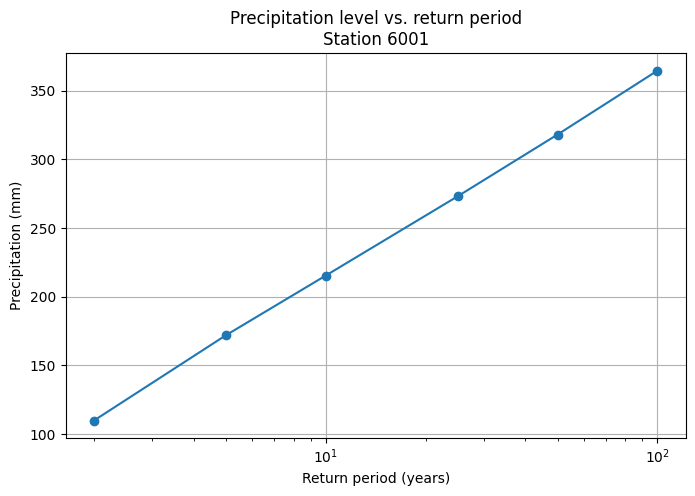

Return period   2 years → 109.75 mm
Return period   5 years → 171.92 mm
Return period  10 years → 215.43 mm
Return period  25 years → 273.21 mm
Return period  50 years → 318.20 mm
Return period 100 years → 364.75 mm


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev

# Paso 1: Cargar datos
df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6001.csv", parse_dates=["date"])

# Paso 2: Limpiar datos
df["pp"] = pd.to_numeric(df["pp"], errors="coerce")
df = df.dropna(subset=["pp"])

# Paso 3: Extraer máximos anuales
df["year"] = df["date"].dt.year
maximos_anuales = df.groupby("year")["pp"].max().dropna()

# Paso 4: Ajustar distribución GEV
params = gev.fit(maximos_anuales)
c, loc, scale = params

# Paso 5: Calcular periodos de retorno
return_periods = np.array([2, 5, 10, 25, 50, 100])
return_levels = gev.ppf(1 - 1 / return_periods, c, loc=loc, scale=scale)

# Paso 6: Visualizar resultados
plt.figure(figsize=(8, 5))
plt.plot(return_periods, return_levels, marker='o')
plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('Precipitation (mm)')
plt.title('Precipitation level vs. return period\nStation 6001')
plt.grid(True)
plt.show()

# Imprimir tabla de resultados
for T, L in zip(return_periods, return_levels):
    print(f"Return period {T:>3} years → {L:.2f} mm")



Tendencia lineal (no estricta) en máximos anuales: creciente, pendiente ~ 0.787 mm/año
Parámetros GEV (MLE): shape=-0.0588, loc=90.52, scale=51.92


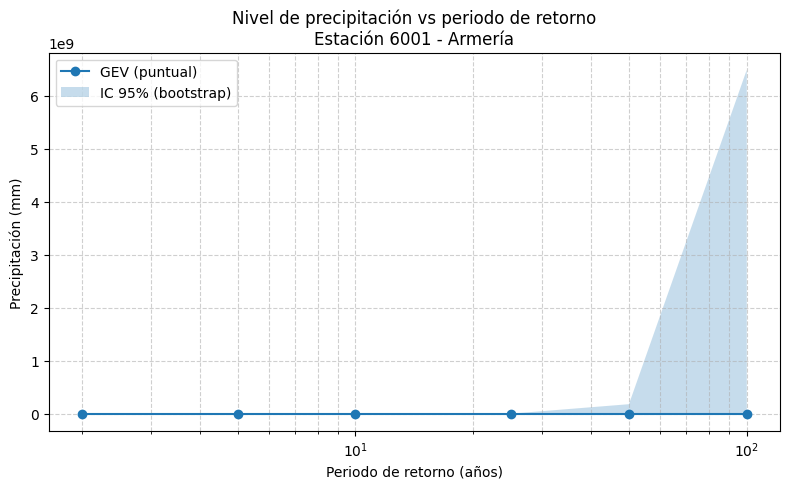

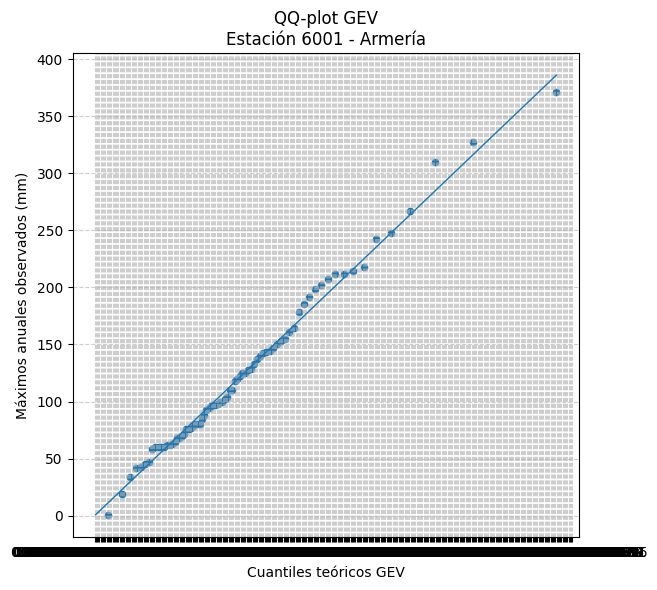

KS (estandarizando con parámetros MLE): D=0.061, p-valor=0.920  (orientativo)

Resultados (niveles de retorno con IC):
 T_anios Nivel_mm IC_low_95%   IC_high_95%
       2   109.75      21.62        127.77
       5   171.92     144.05        732.99
      10   215.43     178.43      39920.61
      25   273.21     218.10    5054554.05
      50   318.20     242.24  183477938.94
     100   364.75     262.38 6485923144.58

Tabla exportada a: /content/return_levels_gev_6001__Armería_20250902_1826.csv


In [ ]:

# Análisis de Períodos de Retorno (GEV) con validaciones y CIs (bootstrap)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
from scipy.stats import kstest
from datetime import datetime

# -------- Parámetros de entrada --------
RUTA_CSV = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6001.csv"
COL_FECHA = "date"         # nombre de la columna de fecha en el CSV
COL_PP = "pp"              # nombre de la columna de precipitación diaria
N_BOOT = 500               # número de réplicas bootstrap para bandas de confianza
ALPHA = 0.05               # nivel para IC (95%)
N_MIN_ANIOS = 10           # mínimo de años recomendados para GEV de máximos anuales
NIVELES_RETORNO = np.array([2, 5, 10, 25, 50, 100])
NOMBRE_ESTACION = "6001 - Armería"

# -------- 1) Cargar datos --------
df = pd.read_csv(RUTA_CSV, parse_dates=[COL_FECHA])
df[COL_PP] = pd.to_numeric(df[COL_PP], errors="coerce")
df = df.dropna(subset=[COL_PP, COL_FECHA])

# -------- 2) Reglas básicas de calidad --------
# Mantener solo valores >= 0 (lluvias negativas no tienen sentido()
df = df[df[COL_PP] >= 0]

# Eliminar duplicados exactos de fecha si existieran (conserva el máximo del día)
df = df.sort_values(COL_FECHA).groupby(COL_FECHA, as_index=False)[COL_PP].max()

# -------- 3) Extraer máximos anuales --------
df["year"] = df[COL_FECHA].dt.year
maximos_anuales = df.groupby("year")[COL_PP].max().dropna()

# Comprobación de cobertura anual (años con datos suficientes)
# (opcional: se podría exigir p.ej. >= 300 días con datos por año)
conteo_anual = df.groupby("year")[COL_PP].count()

# -------- 4) Verificaciones rápidas --------
n_years = len(maximos_anuales)
if n_years < N_MIN_ANIOS:
    print(f"ADVERTENCIA: Solo hay {n_years} años de máximos anuales (< {N_MIN_ANIOS}). "
          "Las estimaciones GEV pueden ser inestables.")

# Chequeo simple de tendencia (estacionariedad) en los máximos anuales
# (solo una regresión lineal rápida como señal; para análisis formal usar MK test)
x = np.arange(n_years)
y = maximos_anuales.values
coef = np.polyfit(x, y, 1)  # pendiente
tendencia = "creciente" if coef[0] > 0 else "decreciente"
print(f"Tendencia lineal (no estricta) en máximos anuales: {tendencia}, pendiente ~ {coef[0]:.3f} mm/año")

# -------- 5) Ajustar GEV por MLE --------
c, loc, scale = gev.fit(maximos_anuales.values)
print(f"Parámetros GEV (MLE): shape={c:.4f}, loc={loc:.2f}, scale={scale:.2f}")

# -------- 6) Niveles de retorno puntuales --------
niveles_retorno = gev.ppf(1 - 1 / NIVELES_RETORNO, c, loc=loc, scale=scale)

# -------- 7) Bandas de confianza por bootstrap --------
rng = np.random.default_rng(42)
boot_levels = np.zeros((N_BOOT, len(NIVELES_RETORNO)))

datos = maximos_anuales.values
for b in range(N_BOOT):
    # Remuestreo con reemplazo de los máximos anuales
    muestra = rng.choice(datos, size=datos.shape[0], replace=True)
    try:
        cb, locb, scaleb = gev.fit(muestra)
        boot_levels[b, :] = gev.ppf(1 - 1 / NIVELES_RETORNO, cb, loc=locb, scale=scaleb)
    except Exception:
        # En caso de problemas numéricos, marcamos NaN para esa réplica
        boot_levels[b, :] = np.nan

# IC por percentiles
low = np.nanpercentile(boot_levels, 100 * (ALPHA/2), axis=0)
high = np.nanpercentile(boot_levels, 100 * (1 - ALPHA/2), axis=0)

# -------- 8) Gráfico: Nivel vs Periodo (con IC) --------
plt.figure(figsize=(8, 5))
plt.plot(NIVELES_RETORNO, niveles_retorno, marker='o', label='GEV (puntual)')
plt.fill_between(NIVELES_RETORNO, low, high, alpha=0.25, label=f'IC {int((1-ALPHA)*100)}% (bootstrap)')
plt.xscale('log')
plt.xlabel('Periodo de retorno (años)')
plt.ylabel('Precipitación (mm)')
plt.title(f'Nivel de precipitación vs periodo de retorno\nEstación {NOMBRE_ESTACION}')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# -------- 9) QQ-plot (probability plot) para diagnóstico --------
# Ordenamos datos y comparamos contra cuantiles teóricos GEV con los parámetros estimados
sorted_data = np.sort(datos)
n = len(sorted_data)
# Probabilidades de no excedencia (plotting positions)
p = (np.arange(1, n+1) - 0.44) / (n + 0.12)  # Gringorten approx
teoricos = gev.ppf(p, c, loc=loc, scale=scale)

plt.figure(figsize=(6, 6))
plt.scatter(teoricos, sorted_data, s=20)
min_ax = min(teoricos.min(), sorted_data.min())
max_ax = max(teoricos.max(), sorted_data.max())
plt.plot([min_ax, max_ax], [min_ax, max_ax], lw=1)  # línea 1:1
plt.xlabel('Cuantiles teóricos GEV')
plt.ylabel('Máximos anuales observados (mm)')
plt.title(f'QQ-plot GEV\nEstación {NOMBRE_ESTACION}')
plt.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.xticks(range(400), np.linspace(0,1,400)) #Agregado por Joan Saladich
plt.show()

# -------- 10) Prueba KS (orientativa) --------
# Nota: KS con parámetros estimados es conservadora.
D, pval = kstest((datos - loc) / scale, 'genextreme', args=(c,))
print(f"KS (estandarizando con parámetros MLE): D={D:.3f}, p-valor={pval:.3f}  (orientativo)")

# -------- 11) Imprimir y exportar tabla de resultados --------
tabla = pd.DataFrame({
    "T_anios": NIVELES_RETORNO,
    "Nivel_mm": niveles_retorno,
    f"IC_low_{int((1-ALPHA)*100)}%": low,
    f"IC_high_{int((1-ALPHA)*100)}%": high
})
print("\nResultados (niveles de retorno con IC):")
print(tabla.to_string(index=False, formatters={
    "Nivel_mm": "{:.2f}".format,
    f"IC_low_{int((1-ALPHA)*100)}%": "{:.2f}".format,
    f"IC_high_{int((1-ALPHA)*100)}%": "{:.2f}".format
}))

fecha_tag = datetime.now().strftime("%Y%m%d_%H%M")
OUT_CSV = f"/content/return_levels_gev_{NOMBRE_ESTACION.replace(' ','_').replace('-','')}_{fecha_tag}.csv"
tabla.to_csv(OUT_CSV, index=False)
print(f"\nTabla exportada a: {OUT_CSV}")


In [ ]:
# ===============================================================
# Batch GEV Return Levels para múltiples estaciones (Carpeta)
# - Recorre CSVs en DIR_IN
# - Calcula máximos anuales, ajusta GEV (MLE)
# - Niveles de retorno + IC bootstrap por estación
# - Exporta: CSV por estación, PNG por estación y CSV maestro
# ===============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import genextreme as gev

# ----------------- PARÁMETROS A EDITAR -----------------
DIR_IN  = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima"  # Carpeta con CSVs
PATRON  = "dat*.csv"      # patrón de archivos, ej. "dat*.csv" o "*.csv"
COL_FECHA = "date"        # nombre de la columna de fecha
COL_PP    = "pp"          # nombre de la columna de precipitación diaria
N_BOOT = 300              # réplicas bootstrap (sube a 500–1000 si quieres IC más estables)
ALPHA  = 0.05             # 95% IC
N_MIN_ANIOS = 10          # mínimo de años recomendados
NIVELES_RETORNO = np.array([2, 5, 10, 25, 50, 100])
SEED = 42                 # semilla reproducible
DIR_OUT = os.path.join(DIR_IN, "_salidas_return_levels")  # carpeta de salida
# -------------------------------------------------------

os.makedirs(DIR_OUT, exist_ok=True)
rng = np.random.default_rng(SEED)
fecha_tag = datetime.now().strftime("%Y%m%d_%H%M")

def procesar_estacion(path_csv):
    """Procesa un CSV de estación: calcula máximos anuales, GEV y niveles de retorno con IC bootstrap.
       Devuelve (tabla_resultados, meta) o (None, meta_err) si falla.
    """
    base = os.path.basename(path_csv)
    station_name = os.path.splitext(base)[0]  # ej. dat6001 -> "dat6001"
    try:
        # 1) Cargar y limpiar
        df = pd.read_csv(path_csv, parse_dates=[COL_FECHA])
        if COL_PP not in df.columns:
            return None, {"station": station_name, "error": f"No existe columna '{COL_PP}'"}
        if COL_FECHA not in df.columns:
            return None, {"station": station_name, "error": f"No existe columna '{COL_FECHA}'"}

        df[COL_PP] = pd.to_numeric(df[COL_PP], errors="coerce")
        df = df.dropna(subset=[COL_PP, COL_FECHA])
        df = df[df[COL_PP] >= 0]

        # Consolidar duplicados por fecha (máximo del día)
        df = df.sort_values(COL_FECHA).groupby(COL_FECHA, as_index=False)[COL_PP].max()

        # 2) Máximos anuales
        df["year"] = df[COL_FECHA].dt.year
        max_ann = df.groupby("year")[COL_PP].max().dropna()
        n_years = len(max_ann)
        if n_years < N_MIN_ANIOS:
            aviso = f"ADVERTENCIA: solo {n_years} años (< {N_MIN_ANIOS}). Estimaciones inestables."
        else:
            aviso = ""

        # Tendencia lineal simple (diagnóstico)
        x = np.arange(n_years)
        y = max_ann.values
        slope = np.polyfit(x, y, 1)[0] if n_years >= 2 else np.nan

        # 3) Ajuste GEV
        c, loc, scale = gev.fit(max_ann.values)

        # 4) Niveles de retorno puntuales
        niveles = gev.ppf(1 - 1 / NIVELES_RETORNO, c, loc=loc, scale=scale)

        # 5) Bootstrap IC
        boot_levels = np.zeros((N_BOOT, len(NIVELES_RETORNO)))
        datos = max_ann.values
        for b in range(N_BOOT):
            muestra = rng.choice(datos, size=datos.shape[0], replace=True)
            try:
                cb, locb, scaleb = gev.fit(muestra)
                boot_levels[b, :] = gev.ppf(1 - 1 / NIVELES_RETORNO, cb, loc=locb, scale=scaleb)
            except Exception:
                boot_levels[b, :] = np.nan

        low = np.nanpercentile(boot_levels, 100*(ALPHA/2), axis=0)
        high = np.nanpercentile(boot_levels, 100*(1-ALPHA/2), axis=0)

        # 6) Tabla por estación
        tabla = pd.DataFrame({
            "station": station_name,
            "T_years": NIVELES_RETORNO,
            "level_mm": niveles,
            f"CI_low_{int((1-ALPHA)*100)}%": low,
            f"CI_high_{int((1-ALPHA)*100)}%": high,
            "gev_shape": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "n_years": n_years,
            "trend_slope_mm_per_year": slope,
            "note": aviso
        })

        # 7) Gráfico por estación
        plt.figure(figsize=(8, 5))
        plt.plot(NIVELES_RETORNO, niveles, marker='o', label='GEV (puntual)')
        plt.fill_between(NIVELES_RETORNO, low, high, alpha=0.25, label=f'IC {int((1-ALPHA)*100)}% (bootstrap)')
        plt.xscale('log')
        plt.xlabel('Periodo de retorno (años)')
        plt.ylabel('Precipitación (mm)')
        plt.title(f'Return Levels GEV – {station_name}\n(n={n_years}, slope≈{slope:.2f} mm/año)')
        plt.grid(True, which='both', ls='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        png_out = os.path.join(DIR_OUT, f"{station_name}_return_levels_{fecha_tag}.png")
        plt.savefig(png_out, dpi=150)
        plt.close()

        # 8) CSV por estación
        csv_out = os.path.join(DIR_OUT, f"{station_name}_return_levels_{fecha_tag}.csv")
        tabla.to_csv(csv_out, index=False)

        meta = {
            "station": station_name,
            "path": path_csv,
            "png": png_out,
            "csv": csv_out,
            "n_years": n_years,
            "slope": slope,
            "shape": c, "loc": loc, "scale": scale,
            "note": aviso
        }
        return tabla, meta

    except Exception as e:
        return None, {"station": station_name, "error": str(e), "path": path_csv}

# ----------------- LOOP PRINCIPAL -----------------
archivos = sorted(glob.glob(os.path.join(DIR_IN, PATRON)))
print(f"Archivos encontrados: {len(archivos)}")

tablas = []
metas = []

for f in archivos:
    tabla, meta = procesar_estacion(f)
    metas.append(meta)
    if tabla is not None:
        tablas.append(tabla)

# ----------------- RESUMEN / EXPORT MAESTRO -----------------
if tablas:
    maestro = pd.concat(tablas, ignore_index=True)
    out_master = os.path.join(DIR_OUT, f"MASTER_return_levels_GEV_{fecha_tag}.csv")
    maestro.to_csv(out_master, index=False)
    print(f"\n>>> CSV maestro con todas las estaciones:\n{out_master}")
    # Resumen corto en pantalla
    print("\nMuestra de resultados:")
    print(maestro.head(12).to_string(index=False,
                                     formatters={"level_mm":"{:.2f}".format,
                                                 f"CI_low_{int((1-ALPHA)*100)}%":"{:.2f}".format,
                                                 f"CI_high_{int((1-ALPHA)*100)}%":"{:.2f}".format}))
else:
    print("No se generaron tablas (¿archivos vacíos o con errores?).")

# Log de metas/errores
log_df = pd.DataFrame(metas)
out_log = os.path.join(DIR_OUT, f"log_proceso_{fecha_tag}.csv")
log_df.to_csv(out_log, index=False)
print(f"\nLog del proceso (incluye errores/advertencias):\n{out_log}")


Archivos encontrados: 37

>>> CSV maestro con todas las estaciones:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels/MASTER_return_levels_GEV_20250822_1619.csv

Muestra de resultados:
station  T_years level_mm CI_low_95%   CI_high_95%  gev_shape   gev_loc  gev_scale  n_years  trend_slope_mm_per_year note
dat6001        2   109.75      21.51        127.01  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001        5   171.92     131.09        611.54  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001       10   215.43     175.46      23736.55  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001       25   273.21     217.70    2481430.44  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001       50   318.20     240.64   78452182.64  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001      100

#Vamos a reprocesar los datos para solucionar este probema:

Problema real: los IC superiores son astronómicamente grandes y crecen de forma explosiva con T (p. ej., T=25 → CI_high ≈ 4.59×10⁶ mm, T=50 → 1.74×10⁸ mm). Eso vuelve inútiles los intervalos, aunque el valor puntual sea verosímil.

Por qué pasa

Con bootstrap no paramétrico de máximos anuales y shape cercano a 0, algunas réplicas ajustan shape > 0 (cola pesada tipo Fréchet) o parámetros inestables; al proyectar a cuantiles altos (T=25, 50, 100) los ppf “explotan” y contaminan los percentiles 95%. No es un “dato real”: es inestabilidad numérica del bootstrap/MLE.

Vamos a arreglarlo primero con IC (bootstrap filtrado y percentiles recortados).

In [ ]:
# ===============================================================
# Batch GEV Return Levels con Bootstrap Robusto (A) y opcional Paramétrico (B)
# - Recorre CSVs en DIR_IN y patrón PATRON
# - Ajusta GEV (MLE) a máximos anuales
# - IC por bootstrap robusto (filtra réplicas inestables)
# - (Opcional) IC por bootstrap paramétrico para comparar
# - Exporta CSV por estación, PNG por estación y un MASTER + LOG
# ===============================================================

import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import genextreme as gev

# ----------------- PARÁMETROS A EDITAR -----------------
DIR_IN  = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima"
PATRON  = "dat*.csv"      # ej. "dat*.csv" o "*.csv"
COL_FECHA = "date"        # nombre de la columna de fecha
COL_PP    = "pp"          # nombre de precipitación diaria
N_MIN_ANIOS = 10          # mínimo recomendado para GEV (máximos anuales)

# Niveles de retorno a estimar
NIVELES_RETORNO = np.array([2, 5, 10, 25, 50, 100], dtype=float)

# Bootstrap
N_BOOT = 500              # réplicas; se puede subir (p.ej., 1000)
ALPHA  = 0.05             # 95% IC
SEED   = 42               # semilla reproducible

# Conmutadores
USAR_BOOT_PARAMETRICO = True   # además del robusto, calcula IC paramétricos (opción B)
PLOT_MAX_T = 100               # máximo T a graficar (para ejes)
# -------------------------------------------------------

DIR_OUT = os.path.join(DIR_IN, "_salidas_return_levels_robusto")
os.makedirs(DIR_OUT, exist_ok=True)
rng = np.random.default_rng(SEED)
fecha_tag = datetime.now().strftime("%Y%m%d_%H%M")

def _bootstrap_robusto(datos, niveles, n_boot, alpha, rng,
                       shape_bounds=(-0.35, 0.35), max_rel_factor=10.0):
    """
    Bootstrap no paramétrico con filtros:
    - parámetros finitos, scale>0
    - shape acotado (cola no extrema)
    - cuantiles finitos/positivos
    - cuantiles no más de max_rel_factor * max_obs (tope relativo)
    Devuelve (low, high, n_aceptadas)
    """
    datos = np.asarray(datos)
    n = len(datos)
    max_obs = np.nanmax(datos)
    keep = []

    for b in range(n_boot):
        muestra = rng.choice(datos, size=n, replace=True)
        try:
            cb, locb, scaleb = gev.fit(muestra)
            if not np.isfinite([cb, locb, scaleb]).all():
                continue
            if scaleb <= 0:
                continue
            if not (shape_bounds[0] <= cb <= shape_bounds[1]):
                continue
            q = gev.ppf(1 - 1/niveles, cb, loc=locb, scale=scaleb)
            if (not np.isfinite(q).all()) or np.any(q <= 0):
                continue
            if np.nanmax(q) > max_rel_factor * max_obs:
                continue
            keep.append(q)
        except Exception:
            continue

    keep = np.array(keep) if len(keep) else np.full((0, len(niveles)), np.nan)
    if keep.shape[0] == 0:
        # Sin réplicas aceptadas: devolvemos NaN
        low = np.full_like(niveles, np.nan, dtype=float)
        high = np.full_like(niveles, np.nan, dtype=float)
        n_acc = 0
    else:
        low  = np.nanpercentile(keep, 100*(alpha/2), axis=0)
        high = np.nanpercentile(keep, 100*(1-alpha/2), axis=0)
        n_acc = keep.shape[0]
    return low, high, n_acc

def _bootstrap_parametrico(c, loc, scale, niveles, n_boot, alpha, rng):
    """Bootstrap paramétrico estable: simula con GEV(c,loc,scale), re-ajusta y toma percentiles."""
    keep = []
    n = 69  # si sensabe n exacto de estación, agregarlo ; o sustitúyelo dinámicamente fuera
    for b in range(n_boot):
        try:
            sim = gev.rvs(c, loc=loc, scale=scale, size=n, random_state=rng)
            cb, locb, scaleb = gev.fit(sim)
            if scaleb <= 0 or not np.isfinite([cb, locb, scaleb]).all():
                continue
            q = gev.ppf(1 - 1/niveles, cb, loc=locb, scale=scaleb)
            if np.isfinite(q).all() and np.all(q > 0):
                keep.append(q)
        except Exception:
            continue

    keep = np.array(keep) if len(keep) else np.full((0, len(niveles)), np.nan)
    if keep.shape[0] == 0:
        low = np.full_like(niveles, np.nan, dtype=float)
        high = np.full_like(niveles, np.nan, dtype=float)
        n_acc = 0
    else:
        low  = np.nanpercentile(keep, 100*(alpha/2), axis=0)
        high = np.nanpercentile(keep, 100*(1-alpha/2), axis=0)
        n_acc = keep.shape[0]
    return low, high, n_acc

def procesar_estacion(path_csv):
    base = os.path.basename(path_csv)
    station = os.path.splitext(base)[0]

    try:
        df = pd.read_csv(path_csv, parse_dates=[COL_FECHA])
        if COL_FECHA not in df.columns or COL_PP not in df.columns:
            return None, {"station": station, "error": "Columnas requeridas no encontradas", "path": path_csv}

        df[COL_PP] = pd.to_numeric(df[COL_PP], errors="coerce")
        df = df.dropna(subset=[COL_FECHA, COL_PP])
        df = df[df[COL_PP] >= 0]
        # Consolidar duplicados por fecha con el máximo
        df = df.sort_values(COL_FECHA).groupby(COL_FECHA, as_index=False)[COL_PP].max()

        # Máximos anuales
        df["year"] = df[COL_FECHA].dt.year
        max_ann = df.groupby("year")[COL_PP].max().dropna().values
        n_years = len(max_ann)
        note = ""
        if n_years < N_MIN_ANIOS:
            note = f"Advertencia: solo {n_years} años (<{N_MIN_ANIOS}). Incertidumbre alta."

        # Tendencia simple
        slope = np.polyfit(np.arange(n_years), max_ann, 1)[0] if n_years >= 2 else np.nan

        # GEV MLE
        c, loc, scale = gev.fit(max_ann)
        if not np.isfinite([c, loc, scale]).all() or scale <= 0:
            return None, {"station": station, "error": "Ajuste GEV inválido", "path": path_csv}

        # Niveles puntuales
        niveles_p = gev.ppf(1 - 1/NIVELES_RETORNO, c, loc=loc, scale=scale)

        # Bootstrap robusto (A)
        lowA, highA, naccA = _bootstrap_robusto(
            max_ann, NIVELES_RETORNO, N_BOOT, ALPHA, rng,
            shape_bounds=(-0.35, 0.35), max_rel_factor=10.0
        )

        # Bootstrap paramétrico (B) opcional
        if USAR_BOOT_PARAMETRICO:
            lowB, highB, naccB = _bootstrap_parametrico(c, loc, scale, NIVELES_RETORNO, N_BOOT, ALPHA, rng)
        else:
            lowB = highB = np.full_like(NIVELES_RETORNO, np.nan)
            naccB = 0

        # Tabla por estación
        out_cols = {
            "station": station,
            "T_years": NIVELES_RETORNO,
            "level_mm": niveles_p,
            "CI_low95_bootA": lowA,
            "CI_high95_bootA": highA,
            "bootA_naccepted": np.repeat(naccA, len(NIVELES_RETORNO)),
            "CI_low95_bootB": lowB,
            "CI_high95_bootB": highB,
            "bootB_naccepted": np.repeat(naccB, len(NIVELES_RETORNO)),
            "gev_shape": np.repeat(c, len(NIVELES_RETORNO)),
            "gev_loc":   np.repeat(loc, len(NIVELES_RETORNO)),
            "gev_scale": np.repeat(scale, len(NIVELES_RETORNO)),
            "n_years":   np.repeat(n_years, len(NIVELES_RETORNO)),
            "trend_slope_mm_per_year": np.repeat(slope, len(NIVELES_RETORNO)),
            "note": np.repeat(note, len(NIVELES_RETORNO))
        }
        tabla = pd.DataFrame(out_cols)

        # Gráfico por estación (usa IC robusto A)
        plt.figure(figsize=(8,5))
        plt.errorbar(NIVELES_RETORNO, niveles_p,
                     yerr=np.vstack([niveles_p - lowA, highA - niveles_p]),
                     fmt='o-', capsize=4, label='GEV (puntual) + IC 95% Boot A')
        plt.xscale('log')
        plt.xlim(NIVELES_RETORNO.min()*0.9, max(PLOT_MAX_T, NIVELES_RETORNO.max())*1.1)
        plt.xlabel('Return period (years)')
        plt.ylabel('Precipitation (mm)')
        subt = f"(n={n_years}, slope≈{slope:.2f} mm/año, shape={c:.3f})"
        plt.title(f'Return Levels GEV – {station}\n{subt}')
        plt.grid(True, which='both', ls='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        png_out = os.path.join(DIR_OUT, f"{station}_return_levels_ROBUST_{fecha_tag}.png")
        plt.savefig(png_out, dpi=150)
        plt.close()

        # CSV por estación
        csv_out = os.path.join(DIR_OUT, f"{station}_return_levels_ROBUST_{fecha_tag}.csv")
        tabla.to_csv(csv_out, index=False)

        meta = {
            "station": station,
            "path": path_csv,
            "png": png_out,
            "csv": csv_out,
            "n_years": n_years,
            "shape": c, "loc": loc, "scale": scale,
            "trend_slope": slope,
            "bootA_naccepted": naccA,
            "bootB_naccepted": naccB,
            "note": note
        }
        return tabla, meta

    except Exception as e:
        return None, {"station": station, "error": str(e), "path": path_csv}

# ----------------- LOOP PRINCIPAL -----------------
archivos = sorted(glob.glob(os.path.join(DIR_IN, PATRON)))
print(f"Archivos encontrados: {len(archivos)}")

tablas, metas = [], []
for f in archivos:
    tabla, meta = procesar_estacion(f)
    metas.append(meta)
    if tabla is not None:
        tablas.append(tabla)

# ----------------- MASTER + LOG -----------------
if tablas:
    maestro = pd.concat(tablas, ignore_index=True)
    out_master = os.path.join(DIR_OUT, f"MASTER_return_levels_GEV_ROBUST_{fecha_tag}.csv")
    maestro.to_csv(out_master, index=False)
    print(f"\n>>> CSV maestro:\n{out_master}")
    print("\nResults:")
    cols_fmt = ["level_mm","CI_low95_bootA","CI_high95_bootA","CI_low95_bootB","CI_high95_bootB"]
    fmts = {c:"{:.2f}".format for c in cols_fmt if c in maestro.columns}
    print(maestro.head(12).to_string(index=False, formatters=fmts))
else:
    print("No se generaron tablas (revisa errores en LOG).")

log_df = pd.DataFrame(metas)
out_log = os.path.join(DIR_OUT, f"log_proceso_ROBUST_{fecha_tag}.csv")
log_df.to_csv(out_log, index=False)
print(f"\nLog del proceso:\n{out_log}")


Archivos encontrados: 37


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



SOLAMENTE VAMOS A MEJORA LA SALIDA DE LA CONSOLA A QUE TENGA SEPARADORES 10000, DEBE SER 10,000


Archivos encontrados: 37

>>> CSV maestro:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/MASTER_return_levels_GEV_ROBUST_20260109_1310.csv

Results:
station  T_years level_mm CI_low95_bootA CI_high95_bootA  bootA_naccepted CI_low95_bootB   CI_high95_bootB  bootB_naccepted  gev_shape   gev_loc  gev_scale  n_years  trend_slope_mm_per_year note
dat6001      2.0   109.75          90.76          125.88              455          17.94            124.77              482  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001      5.0   171.92         146.21          195.77              455          77.11           1753.85              482  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001     10.0   215.43         179.41          249.34              455         174.53         63,086.40              482  -0.058787 90.518101  51.915262       76                 0.7874

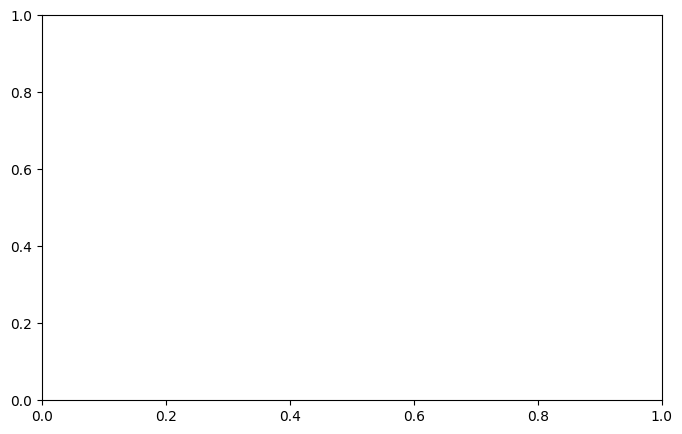

In [ ]:
# ===============================================================
# Batch GEV Return Levels con Bootstrap Robusto (A) y opcional Paramétrico (B)
# - Recorre CSVs en DIR_IN y patrón PATRON
# - Ajusta GEV (MLE) a máximos anuales
# - IC por bootstrap robusto (filtra réplicas inestables)
# - (Opcional) IC por bootstrap paramétrico para comparar
# - Exporta CSV por estación, PNG por estación y un MASTER + LOG
# ===============================================================

import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import genextreme as gev

# ----------------- PARÁMETROS A EDITAR -----------------
DIR_IN  = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima"
PATRON  = "dat*.csv"      # ej. "dat*.csv" o "*.csv"
COL_FECHA = "date"        # nombre de la columna de fecha
COL_PP    = "pp"          # nombre de precipitación diaria
N_MIN_ANIOS = 10          # mínimo recomendado para GEV (máximos anuales)

# Niveles de retorno a estimar
NIVELES_RETORNO = np.array([2, 5, 10, 25, 50, 100], dtype=float)

# Bootstrap
N_BOOT = 500              # réplicas; se puede subir (p.ej., 1000)
ALPHA  = 0.05             # 95% IC
SEED   = 42               # semilla reproducible

# Conmutadores
USAR_BOOT_PARAMETRICO = True   # además del robusto, calcula IC paramétricos (opción B)
PLOT_MAX_T = 100               # máximo T a graficar (para ejes)
# -------------------------------------------------------

DIR_OUT = os.path.join(DIR_IN, "_salidas_return_levels_robusto")
os.makedirs(DIR_OUT, exist_ok=True)
rng = np.random.default_rng(SEED)
fecha_tag = datetime.now().strftime("%Y%m%d_%H%M")

def _bootstrap_robusto(datos, niveles, n_boot, alpha, rng,
                       shape_bounds=(-0.35, 0.35), max_rel_factor=10.0):
    """
    Bootstrap no paramétrico con filtros:
    - parámetros finitos, scale>0
    - shape acotado (cola no extrema)
    - cuantiles finitos/positivos
    - cuantiles no más de max_rel_factor * max_obs (tope relativo)
    Devuelve (low, high, n_aceptadas)
    """
    datos = np.asarray(datos)
    n = len(datos)
    max_obs = np.nanmax(datos)
    keep = []

    for b in range(n_boot):
        muestra = rng.choice(datos, size=n, replace=True)
        try:
            cb, locb, scaleb = gev.fit(muestra)
            if not np.isfinite([cb, locb, scaleb]).all():
                continue
            if scaleb <= 0:
                continue
            if not (shape_bounds[0] <= cb <= shape_bounds[1]):
                continue
            q = gev.ppf(1 - 1/niveles, cb, loc=locb, scale=scaleb)
            if (not np.isfinite(q).all()) or np.any(q <= 0):
                continue
            if np.nanmax(q) > max_rel_factor * max_obs:
                continue
            keep.append(q)
        except Exception:
            continue

    keep = np.array(keep) if len(keep) else np.full((0, len(niveles)), np.nan)
    if keep.shape[0] == 0:
        # Sin réplicas aceptadas: devolvemos NaN
        low = np.full_like(niveles, np.nan, dtype=float)
        high = np.full_like(niveles, np.nan, dtype=float)
        n_acc = 0
    else:
        low  = np.nanpercentile(keep, 100*(alpha/2), axis=0)
        high = np.nanpercentile(keep, 100*(1-alpha/2), axis=0)
        n_acc = keep.shape[0]
    return low, high, n_acc

def _bootstrap_parametrico(c, loc, scale, niveles, n_boot, alpha, rng):
    """Bootstrap paramétrico estable: simula con GEV(c,loc,scale), re-ajusta y toma percentiles."""
    keep = []
    n = 69  # si sensabe n exacto de estación, agregarlo ; o sustitúyelo dinámicamente fuera
    for b in range(n_boot):
        try:
            sim = gev.rvs(c, loc=loc, scale=scale, size=n, random_state=rng)
            cb, locb, scaleb = gev.fit(sim)
            if scaleb <= 0 or not np.isfinite([cb, locb, scaleb]).all():
                continue
            q = gev.ppf(1 - 1/niveles, cb, loc=locb, scale=scaleb)
            if np.isfinite(q).all() and np.all(q > 0):
                keep.append(q)
        except Exception:
            continue

    keep = np.array(keep) if len(keep) else np.full((0, len(niveles)), np.nan)
    if keep.shape[0] == 0:
        low = np.full_like(niveles, np.nan, dtype=float)
        high = np.full_like(niveles, np.nan, dtype=float)
        n_acc = 0
    else:
        low  = np.nanpercentile(keep, 100*(alpha/2), axis=0)
        high = np.nanpercentile(keep, 100*(1-alpha/2), axis=0)
        n_acc = keep.shape[0]
    return low, high, n_acc

def procesar_estacion(path_csv):
    base = os.path.basename(path_csv)
    station = os.path.splitext(base)[0]

    try:
        df = pd.read_csv(path_csv, parse_dates=[COL_FECHA])
        if COL_FECHA not in df.columns or COL_PP not in df.columns:
            return None, {"station": station, "error": "Columnas requeridas no encontradas", "path": path_csv}

        df[COL_PP] = pd.to_numeric(df[COL_PP], errors="coerce")
        df = df.dropna(subset=[COL_FECHA, COL_PP])
        df = df[df[COL_PP] >= 0]
        # Consolidar duplicados por fecha con el máximo
        df = df.sort_values(COL_FECHA).groupby(COL_FECHA, as_index=False)[COL_PP].max()

        # Máximos anuales
        df["year"] = df[COL_FECHA].dt.year
        max_ann = df.groupby("year")[COL_PP].max().dropna().values
        n_years = len(max_ann)
        note = ""
        if n_years < N_MIN_ANIOS:
            note = f"Advertencia: solo {n_years} años (<{N_MIN_ANIOS}). Incertidumbre alta."

        # Tendencia simple
        slope = np.polyfit(np.arange(n_years), max_ann, 1)[0] if n_years >= 2 else np.nan

        # GEV MLE
        c, loc, scale = gev.fit(max_ann)
        if not np.isfinite([c, loc, scale]).all() or scale <= 0:
            return None, {"station": station, "error": "Ajuste GEV inválido", "path": path_csv}

        # Niveles puntuales
        niveles_p = gev.ppf(1 - 1/NIVELES_RETORNO, c, loc=loc, scale=scale)

        # Bootstrap robusto (A)
        lowA, highA, naccA = _bootstrap_robusto(
            max_ann, NIVELES_RETORNO, N_BOOT, ALPHA, rng,
            shape_bounds=(-0.35, 0.35), max_rel_factor=10.0
        )

        # Bootstrap paramétrico (B) opcional
        if USAR_BOOT_PARAMETRICO:
            lowB, highB, naccB = _bootstrap_parametrico(c, loc, scale, NIVELES_RETORNO, N_BOOT, ALPHA, rng)
        else:
            lowB = highB = np.full_like(NIVELES_RETORNO, np.nan)
            naccB = 0

        # Tabla por estación
        out_cols = {
            "station": station,
            "T_years": NIVELES_RETORNO,
            "level_mm": niveles_p,
            "CI_low95_bootA": lowA,
            "CI_high95_bootA": highA,
            "bootA_naccepted": np.repeat(naccA, len(NIVELES_RETORNO)),
            "CI_low95_bootB": lowB,
            "CI_high95_bootB": highB,
            "bootB_naccepted": np.repeat(naccB, len(NIVELES_RETORNO)),
            "gev_shape": np.repeat(c, len(NIVELES_RETORNO)),
            "gev_loc":   np.repeat(loc, len(NIVELES_RETORNO)),
            "gev_scale": np.repeat(scale, len(NIVELES_RETORNO)),
            "n_years":   np.repeat(n_years, len(NIVELES_RETORNO)),
            "trend_slope_mm_per_year": np.repeat(slope, len(NIVELES_RETORNO)),
            "note": np.repeat(note, len(NIVELES_RETORNO))
        }
        tabla = pd.DataFrame(out_cols)

        # Gráfico por estación (usa IC robusto A)
        plt.figure(figsize=(8,5))
        plt.errorbar(NIVELES_RETORNO, niveles_p,
                     yerr=np.vstack([niveles_p - lowA, highA - niveles_p]),
                     fmt='o-', capsize=4, label='GEV (puntual) + IC 95% Boot A')
        plt.xscale('log')
        plt.xlim(NIVELES_RETORNO.min()*0.9, max(PLOT_MAX_T, NIVELES_RETORNO.max())*1.1)
        plt.xlabel('Return period (years)')
        plt.ylabel('Precipitation (mm)')
        subt = f"(n={n_years}, slope≈{slope:.2f} mm/year, shape={c:.3f})"
        plt.title(f'Return Levels GEV – {station}\n{subt}')
        plt.grid(True, which='both', ls='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        png_out = os.path.join(DIR_OUT, f"{station}_return_levels_ROBUST_{fecha_tag}.png")
        plt.savefig(png_out, dpi=150)
        plt.close()

        # CSV por estación
        csv_out = os.path.join(DIR_OUT, f"{station}_return_levels_ROBUST_{fecha_tag}.csv")
        tabla.to_csv(csv_out, index=False)

        meta = {
            "station": station,
            "path": path_csv,
            "png": png_out,
            "csv": csv_out,
            "n_years": n_years,
            "shape": c, "loc": loc, "scale": scale,
            "trend_slope": slope,
            "bootA_naccepted": naccA,
            "bootB_naccepted": naccB,
            "note": note
        }
        return tabla, meta

    except Exception as e:
        return None, {"station": station, "error": str(e), "path": path_csv}

# ----------------- LOOP PRINCIPAL -----------------
archivos = sorted(glob.glob(os.path.join(DIR_IN, PATRON)))
print(f"Archivos encontrados: {len(archivos)}")

tablas, metas = [], []
for f in archivos:
    tabla, meta = procesar_estacion(f)
    metas.append(meta)
    if tabla is not None:
        tablas.append(tabla)

# ----------------- MASTER + LOG -----------------
if tablas:
    maestro = pd.concat(tablas, ignore_index=True)
    out_master = os.path.join(DIR_OUT, f"MASTER_return_levels_GEV_ROBUST_{fecha_tag}.csv")
    maestro.to_csv(out_master, index=False)
    print(f"\n>>> CSV maestro:\n{out_master}")
    print("\nResults:")

    cols_fmt = ["level_mm", "CI_low95_bootA", "CI_high95_bootA", "CI_low95_bootB", "CI_high95_bootB"]

    def fmt_2dec_commas_5plus(x):
        # Maneja NaN
        if pd.isna(x):
            return "NaN"
        try:
            v = float(x)
        except Exception:
            return str(x)

        # Solo separa miles si tiene 5+ dígitos (>= 10,000)
        if abs(v) >= 10000:
            return f"{v:,.2f}"   # 10,000.00
        else:
            return f"{v:.2f}"    # 9876.00 (sin coma)

    fmts = {c: fmt_2dec_commas_5plus for c in cols_fmt if c in maestro.columns}
    print(maestro.head(12).to_string(index=False, formatters=fmts))
else:
    print("No se generaron tablas (revisa errores en LOG).")

log_df = pd.DataFrame(metas)
out_log = os.path.join(DIR_OUT, f"log_proceso_ROBUST_{fecha_tag}.csv")
log_df.to_csv(out_log, index=False)
print(f"\nLog del proceso:\n{out_log}")



# ¿Qué es el periodo de retorno?



El periodo de retorno
𝑇
T de un evento (como una lluvia intensa) es el tiempo promedio esperado entre dos eventos de igual o mayor magnitud. En otras palabras:

Un evento con un periodo de retorno de T años tiene una probabilidad de
1
/
𝑇
1/T de ocurrir en cualquier año dado.

# Ejemplos prácticos

Una lluvia extrema con un periodo de retorno de 10 años significa que, en promedio, se espera que ocurra una vez cada 10 años.

Un evento con periodo de retorno de 100 años (como una lluvia torrencial o una inundación grave) no significa que solo ocurra una vez cada 100 años, sino que cada año hay un 1% de probabilidad de que ocurra.

# Probabilidad de Excedencias

## Paso 1: calcular excedencia para la estación 6001 usando dat6001.csv
La excedencia se refiere a la proporción de días en que se registró lluvia intensa (≥ 50 mm) respecto al total de días registrados.

In [ ]:
import pandas as pd

# Load daily data from station 6001
df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6001.csv")

# PRECIP converted to numeric format
df["pp"] = pd.to_numeric(df["pp"], errors="coerce")

# Filter valid values
df_validos = df.dropna(subset=["pp"])

# Calculate total number of days and days with rainfall ≥ 50 mm
total_dias = len(df_validos)
dias_excedencia = (df_validos["pp"] >= 50).sum()

# Calculate exceedance proportion
excedencia_6001 = dias_excedencia / total_dias

print(f"Total days: {total_dias}")
print(f"Days with rainfall ≥ 50 mm: {dias_excedencia}")
print(f"Exceedance probability – Station 6001: {excedencia_6001:.4f}")


Total days: 26225
Days with rainfall ≥ 50 mm: 268
Exceedance probability – Station 6001: 0.0102


## Paso 2: agregar el resultado a coordenadas_estaciones.csv y graficar

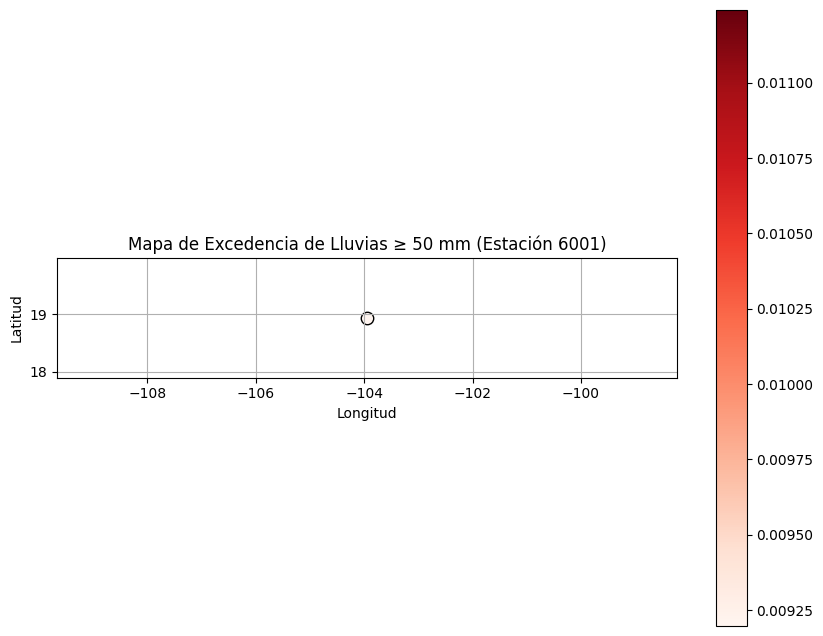

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Cargar coordenadas
df_coord = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/coordenadas_estaciones.csv")

# Crear columna de excedencia solo para esta estación como ejemplo
df_coord["EXCEDENCIA_50MM"] = df_coord["CLAVE"].apply(lambda x: excedencia_6001 if x == 6001 else None)

# Crear geometría
geometry = [Point(xy) for xy in zip(df_coord["LONGITUD"], df_coord["LATITUD"])]
gdf = gpd.GeoDataFrame(df_coord, geometry=geometry, crs="EPSG:4326")

# Graficar
fig, ax = plt.subplots(figsize=(10, 8))
gdf.dropna(subset=["EXCEDENCIA_50MM"]).plot(
    ax=ax, column="EXCEDENCIA_50MM", cmap="Reds", legend=True,
    edgecolor='black', markersize=80
)
plt.title("Mapa de Excedencia de Lluvias ≥ 50 mm (Estación 6001)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()


📍 ¿Qué muestra la imagen?
La gráfica muestra un mapa georreferenciado con un solo punto: la estación 6001 (Armería).

El punto está ubicado en su posición geográfica real (latitud ~19°, longitud ~-104°).

El color del punto representa la frecuencia relativa de días con lluvia intensa (≥ 50 mm).

La barra lateral de color (colorbar) indica la escala de probabilidad de excedencia, desde el color más claro (baja frecuencia) al más oscuro (mayor frecuencia).

🎯 ¿Qué significa el valor de excedencia?
Según la escala del mapa:

El punto tiene una probabilidad de excedencia de aproximadamente 0.01 (es decir, 1%).

Esto significa que 1 de cada 100 días, en promedio, ocurre una lluvia intensa (≥ 50 mm) en la estación 6001.

# CÓDIGO PARA MAPA DE EXCEDENCIA DE ESTACIONES DE COLIMA

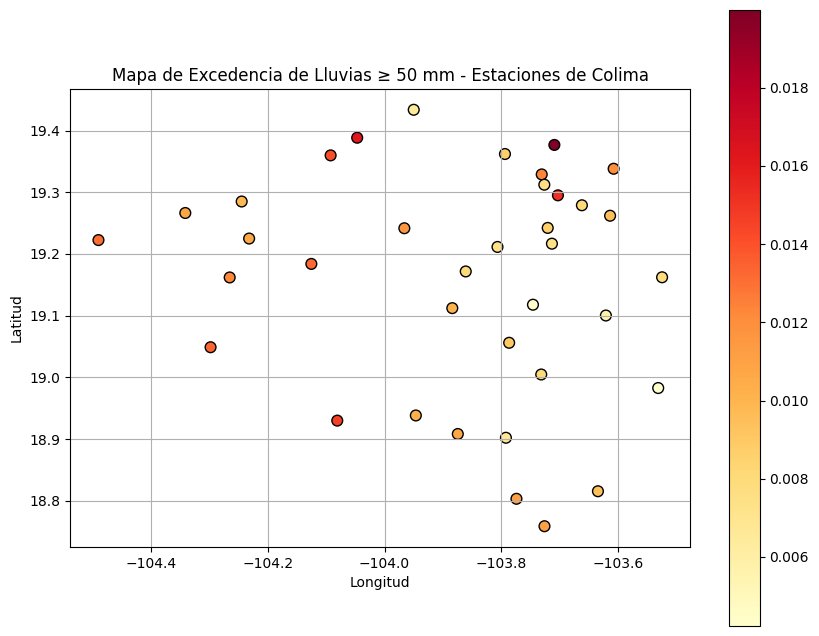

In [ ]:
# Paso 1: Librerías necesarias
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import matplotlib.pyplot as plt

# Paso 2: Ruta donde están los archivos de estaciones
carpeta_estaciones = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima"  # cambia según tu entorno
archivo_coordenadas = os.path.join(carpeta_estaciones, "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")

# Paso 3: Cargar coordenadas
df_coords = pd.read_excel(archivo_coordenadas)

# Paso 4: Inicializar diccionario para resultados
resultados = []

# Paso 5: Procesar cada archivo de estación
for clave in df_coords["CLAVE"]:
    nombre_archivo = f"{clave}_{df_coords.loc[df_coords['CLAVE'] == clave, 'NOMBRE'].values[0].replace(' ', '_').upper()}.xlsx"
    ruta = os.path.join(carpeta_estaciones, nombre_archivo)

    if not os.path.exists(ruta):
        print(f"⚠️ Archivo no encontrado: {ruta}")
        continue

    try:
        df = pd.read_excel(ruta, sheet_name="Datos Clima")
        df["PRECIP"] = pd.to_numeric(df["PRECIP"], errors="coerce")
        total_dias = df["PRECIP"].count()
        dias_excedencia = (df["PRECIP"] >= 50).sum()
        probabilidad = dias_excedencia / total_dias if total_dias > 0 else None
        resultados.append({"CLAVE": clave, "EXCEDENCIA_50MM": probabilidad})
    except Exception as e:
        print(f"❌ Error procesando {nombre_archivo}: {e}")

# Paso 6: Unir resultados con coordenadas
df_excedencia = pd.DataFrame(resultados)
df_final = pd.merge(df_coords, df_excedencia, on="CLAVE", how="left")

# Paso 7: Crear GeoDataFrame
geometry = [Point(xy) for xy in zip(df_final["LONGITUD"], df_final["LATITUD"])]
gdf = gpd.GeoDataFrame(df_final, geometry=geometry, crs="EPSG:4326")

# Paso 8: Graficar mapa
fig, ax = plt.subplots(figsize=(10, 8))
gdf.dropna(subset=["EXCEDENCIA_50MM"]).plot(
    ax=ax, column="EXCEDENCIA_50MM", cmap="YlOrRd", legend=True,
    edgecolor='black', markersize=60
)
plt.title("Mapa de Excedencia de Lluvias ≥ 50 mm - Estaciones de Colima")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()

#Guardar archivo
df_final.to_csv("excedencia_colima.csv", index=False)



# Generando Mapa


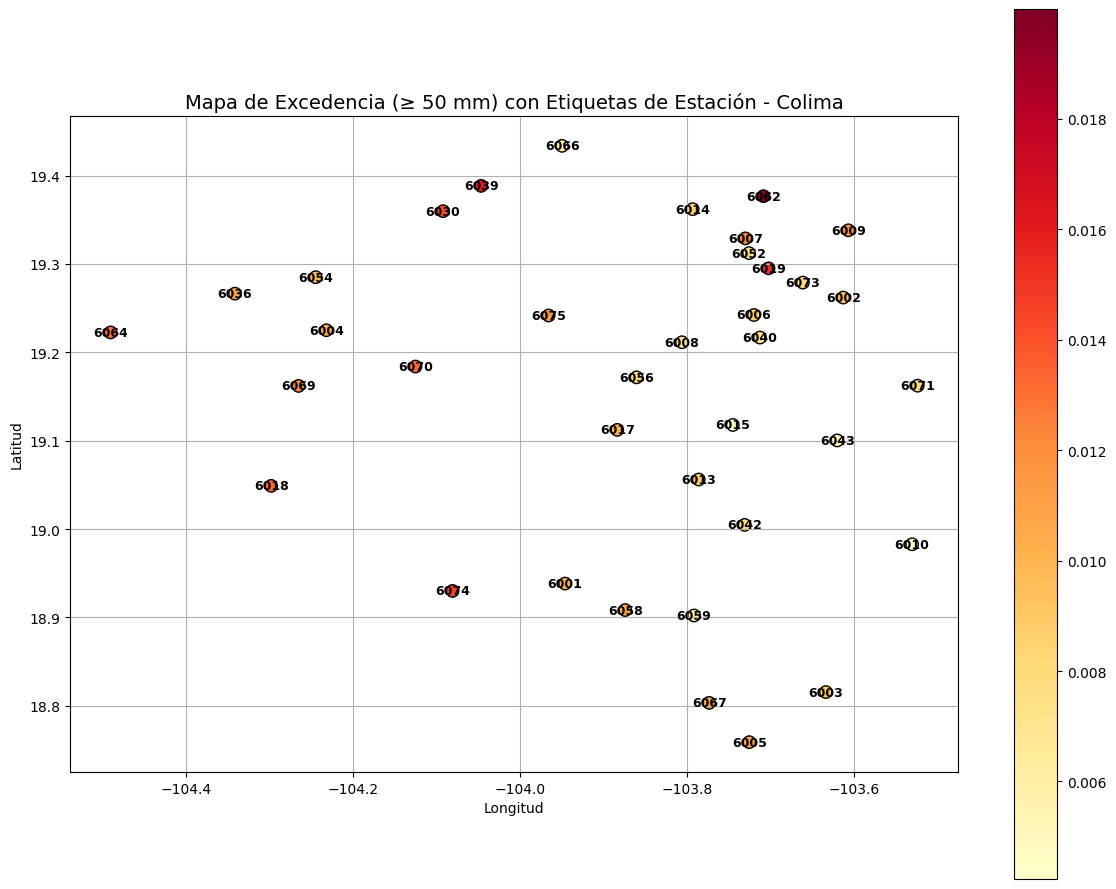

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import os

# -------------------
# Rutas
# -------------------
carpeta_estaciones = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima"  # cambia según tu entorno
archivo_coordenadas = os.path.join(carpeta_estaciones, "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")

# (Opcional) Ruta a archivo shapefile o geojson de Colima
# Ejemplo con geojson descargado previamente de INEGI o GADM
# archivo_colima_mapa = "/content/colima_boundary.geojson"

# -------------------
# Cargar coordenadas y preparar datos
# -------------------
df_coords = pd.read_excel(archivo_coordenadas)
resultados = []

for clave in df_coords["CLAVE"]:
    nombre_archivo = f"{clave}_{df_coords.loc[df_coords['CLAVE'] == clave, 'NOMBRE'].values[0].replace(' ', '_').upper()}.xlsx"
    ruta = os.path.join(carpeta_estaciones, nombre_archivo)

    if not os.path.exists(ruta):
        continue

    try:
        df = pd.read_excel(ruta, sheet_name="Datos Clima")
        df["PRECIP"] = pd.to_numeric(df["PRECIP"], errors="coerce")
        total_dias = df["PRECIP"].count()
        dias_excedencia = (df["PRECIP"] >= 50).sum()
        probabilidad = dias_excedencia / total_dias if total_dias > 0 else None
        resultados.append({"CLAVE": clave, "EXCEDENCIA_50MM": probabilidad})
    except Exception as e:
        print(f"Error procesando {nombre_archivo}: {e}")

# -------------------
# Unir resultados y convertir a GeoDataFrame
# -------------------
df_excedencia = pd.DataFrame(resultados)
df_final = pd.merge(df_coords, df_excedencia, on="CLAVE", how="left")
geometry = [Point(xy) for xy in zip(df_final["LONGITUD"], df_final["LATITUD"])]
gdf = gpd.GeoDataFrame(df_final, geometry=geometry, crs="EPSG:4326")

# -------------------
# Cargar el mapa base del estado de Colima (shapefile)
# -------------------
# mapa_colima = gpd.read_file(archivo_colima_mapa)

# -------------------
# Mapa dinámico con etiquetas
# -------------------
fig, ax = plt.subplots(figsize=(12, 9))

# mapa_colima.plot(ax=ax, color="whitesmoke", edgecolor="gray")  # Opcional: base del estado
gdf.dropna(subset=["EXCEDENCIA_50MM"]).plot(
    ax=ax,
    column="EXCEDENCIA_50MM",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    markersize=80
)

# Agregar etiquetas (CLAVE) sobre cada punto
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["CLAVE"]):
    ax.text(x, y, str(label), fontsize=9, ha='center', va='center', color='black', fontweight='bold')

plt.title("Mapa de Excedencia (≥ 50 mm) con Etiquetas de Estación - Colima", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.tight_layout()
plt.show()


# Ahora vamos a visualizar un mapa con:

* El contorno del estado de Colima (desde un .gpkg)

* Las estaciones meteorológicas con sus coordenadas

* El número de estación (CLAVE) como etiqueta

* Un color que indique la probabilidad de excedencia (≥ 50 mm)


In [ ]:
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 35.4 MB/s eta 0:00:00


In [ ]:
!pip install geopandas fiona shapely pyproj

['CLAVE', 'NOMBRE_x', 'ESTADO_x', 'LATITUD_x', 'LONGITUD_x', 'NOMBRE_y', 'ESTADO_y', 'LATITUD_y', 'LONGITUD_y', 'EXCEDENCIA_50MM']
   CLAVE                  NOMBRE  ESTADO    LATITUD    LONGITUD  \
0   6001                 ARMERIA  COLIMA  18.938333 -103.946389   
1   6002              BUENAVISTA  COLIMA  19.261944 -103.613333   
2   6003              CALLEJONES  COLIMA  18.815556 -103.634167   
3   6004  CAMOTLAN DE MIRAFLORES  COLIMA  19.225000 -104.232222   
4   6005         CERRO DE ORTEGA  COLIMA  18.758889 -103.725833   

   EXCEDENCIA_50MM                     geometry  
0         0.010219  POINT (-103.94639 18.93833)  
1         0.009513  POINT (-103.61333 19.26194)  
2         0.009432  POINT (-103.63417 18.81556)  
3         0.010597    POINT (-104.23222 19.225)  
4         0.011054  POINT (-103.72583 18.75889)  


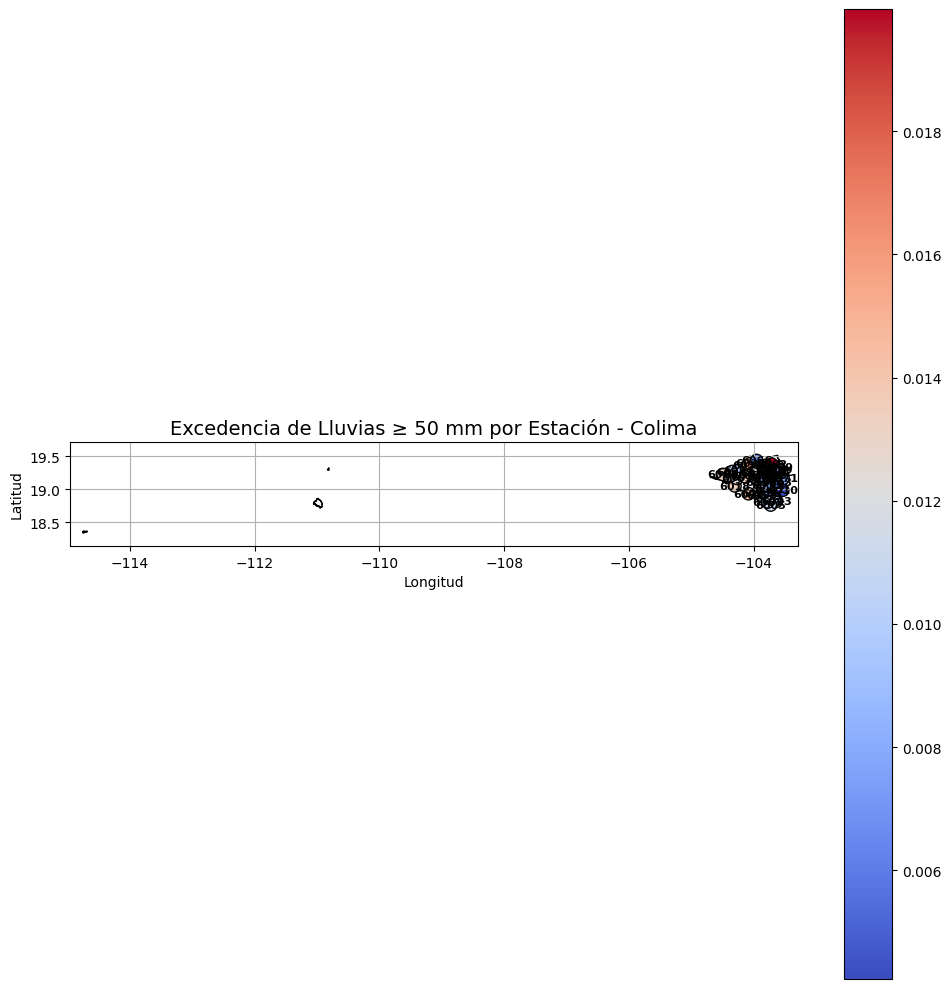

In [ ]:
import geopandas as gpd
import pandas as pd
import fiona
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 1. Leer archivo GPKG de todo México
gdf_mex = gpd.read_file("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/gadm41_MEX.gpkg", layer="ADM_ADM_1")

# 2. Filtrar Colima
gdf_colima = gdf_mex[gdf_mex["NAME_1"].str.upper() == "COLIMA"].copy()

# Leer coordenadas
df_coords = pd.read_excel("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")

# Leer probabilidades calculadas (asegúrate de tener esto guardado)
df_excedencias = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

# Unir coordenadas + probabilidad
df_merged = pd.merge(df_coords, df_excedencias, on="CLAVE", how="left")
print(df_merged.columns.tolist())

# -------------------------------
# Limpiar columnas duplicadas
# -------------------------------
df_merged = df_merged.drop(columns=["NOMBRE_y", "ESTADO_y", "LATITUD_y", "LONGITUD_y"])
df_merged = df_merged.rename(columns={
    "NOMBRE_x": "NOMBRE",
    "ESTADO_x": "ESTADO",
    "LATITUD_x": "LATITUD",
    "LONGITUD_x": "LONGITUD"
})

#  Crear geometría con LATITUD y LONGITUD
geometry = [Point(xy) for xy in zip(df_merged["LONGITUD"], df_merged["LATITUD"])]
gdf_estaciones = gpd.GeoDataFrame(df_merged, geometry=geometry, crs="EPSG:4326")

# Verifica
print(gdf_estaciones.head())

# ------------------------------
# Graficar
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Capa base: contorno de Colima
gdf_colima.plot(ax=ax, color="whitesmoke", edgecolor="black")

# Estaciones con color según excedencia
gdf_estaciones.dropna(subset=["EXCEDENCIA_50MM"]).plot(
    ax=ax,
    column="EXCEDENCIA_50MM",
    cmap="coolwarm",  # Puedes cambiar colormap si deseas
    legend=True,
    markersize=80,
    edgecolor="black"
)

# Agregar etiquetas con CLAVE
for x, y, label in zip(
    gdf_estaciones.geometry.x,
    gdf_estaciones.geometry.y,
    gdf_estaciones["CLAVE"]
):
    ax.text(x, y, str(label), fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# Título y etiquetas
ax.set_title("Excedencia de Lluvias ≥ 50 mm por Estación - Colima", fontsize=14)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Ajustar límites al área de Colima
minx, miny, maxx, maxy = gdf_colima.total_bounds
ax.set_xlim(minx - 0.2, maxx + 0.2)
ax.set_ylim(miny - 0.2, maxy + 0.2)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
!apt-get install libgeos-dev -y
!pip install basemap basemap-data-hires

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgeos-dev is already the newest version (3.12.1-1~jammy0).
libgeos-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 42.3 MB/s eta 0:00:00


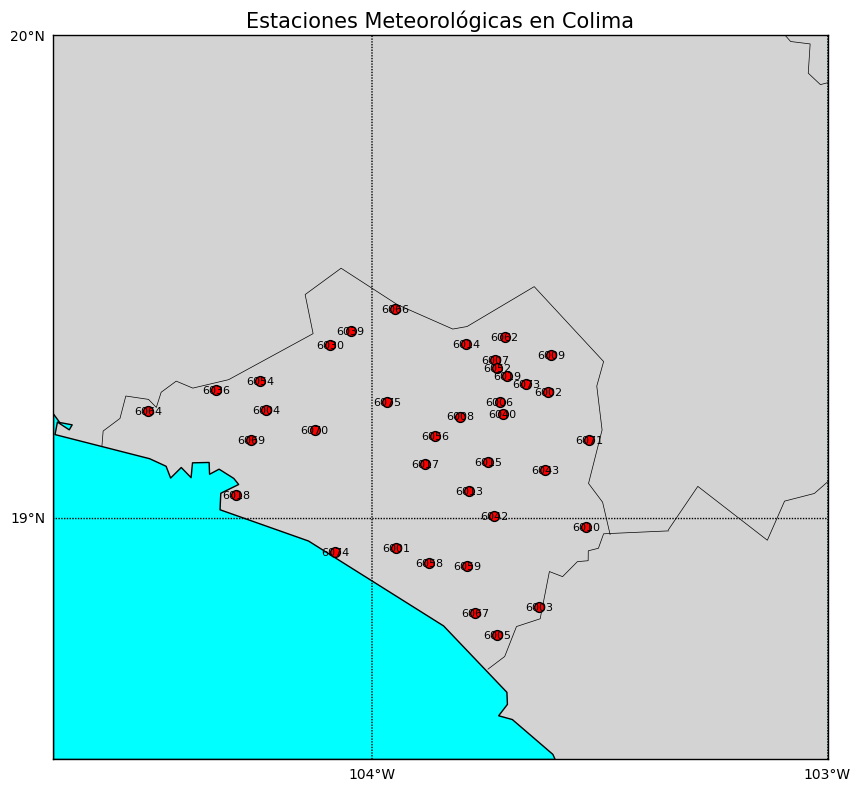

In [ ]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import pandas as pd

# Cargar coordenadas
df = pd.read_excel("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")  # o el path donde lo tengas

# Crear figura
plt.figure(figsize=(10, 10))

# Crear Basemap centrado en Colima
m = Basemap(projection='merc',
            llcrnrlat=18.5, urcrnrlat=20.0,
            llcrnrlon=-104.7, urcrnrlon=-103.0,
            resolution='i')

m.drawcoastlines()
m.drawcountries()
m.drawstates()
m.drawmapboundary(fill_color='aqua')
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawparallels(range(18, 21), labels=[1, 0, 0, 0])
m.drawmeridians(range(-105, -102), labels=[0, 0, 0, 1])

# Convertir coordenadas de estaciones
x, y = m(df["LONGITUD"].values, df["LATITUD"].values)

# Plotear puntos de estaciones
m.scatter(x, y, s=50, c='red', marker='o', edgecolors='black', zorder=5)

# Agregar etiquetas de clave
for xi, yi, clave in zip(x, y, df["CLAVE"]):
    plt.text(xi, yi, str(clave), fontsize=8, ha='center', va='center', zorder=6)

# Título
plt.title("Estaciones Meteorológicas en Colima", fontsize=15)
plt.show()


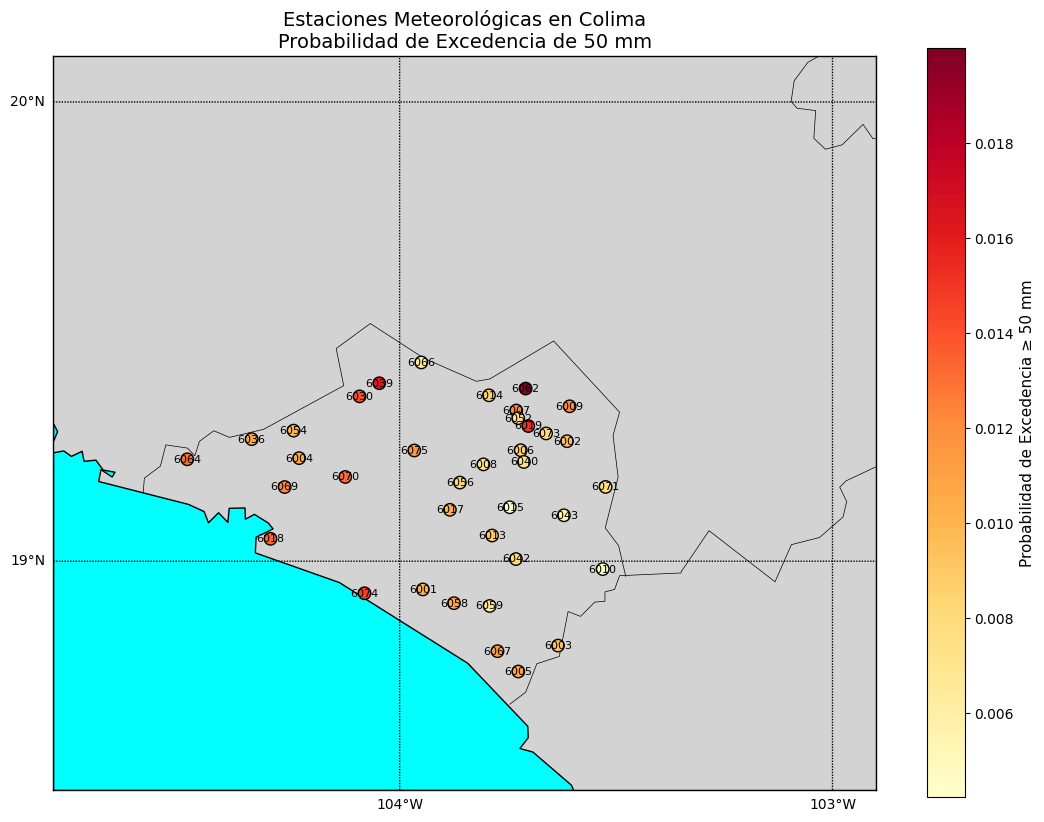

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ----------------------------
# 1. Cargar los datos
# ----------------------------
# Ruta a tus archivos en Drive o local
ruta_coords = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx"
ruta_excedencia = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv"

# Leer archivos
df_coords = pd.read_excel(ruta_coords)
df_excedencia = pd.read_csv(ruta_excedencia)

# Unir por clave de estación
df_final = pd.merge(df_coords, df_excedencia, on="CLAVE", how="left")

# ----------------------------
# 2. Crear figura y mapa
# ----------------------------
plt.figure(figsize=(11, 11))

m = Basemap(projection='merc',
            llcrnrlat=18.5, urcrnrlat=20.1,
            llcrnrlon=-104.8, urcrnrlon=-102.9,
            resolution='i')

m.drawcoastlines()
m.drawcountries()
m.drawstates()
m.drawmapboundary(fill_color='aqua')
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawparallels(range(18, 21), labels=[1, 0, 0, 0])
m.drawmeridians(range(-105, -102), labels=[0, 0, 0, 1])

# ----------------------------
# 3. Graficar estaciones
# ----------------------------
# Usar las columnas correctas
x, y = m(df_final["LONGITUD_x"].values, df_final["LATITUD_x"].values)

# Puntos coloreados por excedencia
sc = m.scatter(x, y,
               c=df_final["EXCEDENCIA_50MM"],
               cmap="YlOrRd",
               s=80,
               edgecolors="black",
               zorder=5)

# Etiquetas
for xi, yi, clave in zip(x, y, df_final["CLAVE"]):
    plt.text(xi, yi, str(clave), fontsize=8, ha='center', va='center', color='black', zorder=6)

# Barra de color
cbar = plt.colorbar(sc, shrink=0.7)
cbar.set_label("Probabilidad de Excedencia ≥ 50 mm", fontsize=11)

# Título
plt.title("Estaciones Meteorológicas en Colima\nProbabilidad de Excedencia de 50 mm", fontsize=14)
plt.tight_layout()
plt.show()


# Mapa de interpolación de probabilidad de excedencia usando el metodo griddata con interpolación lineal en Python.



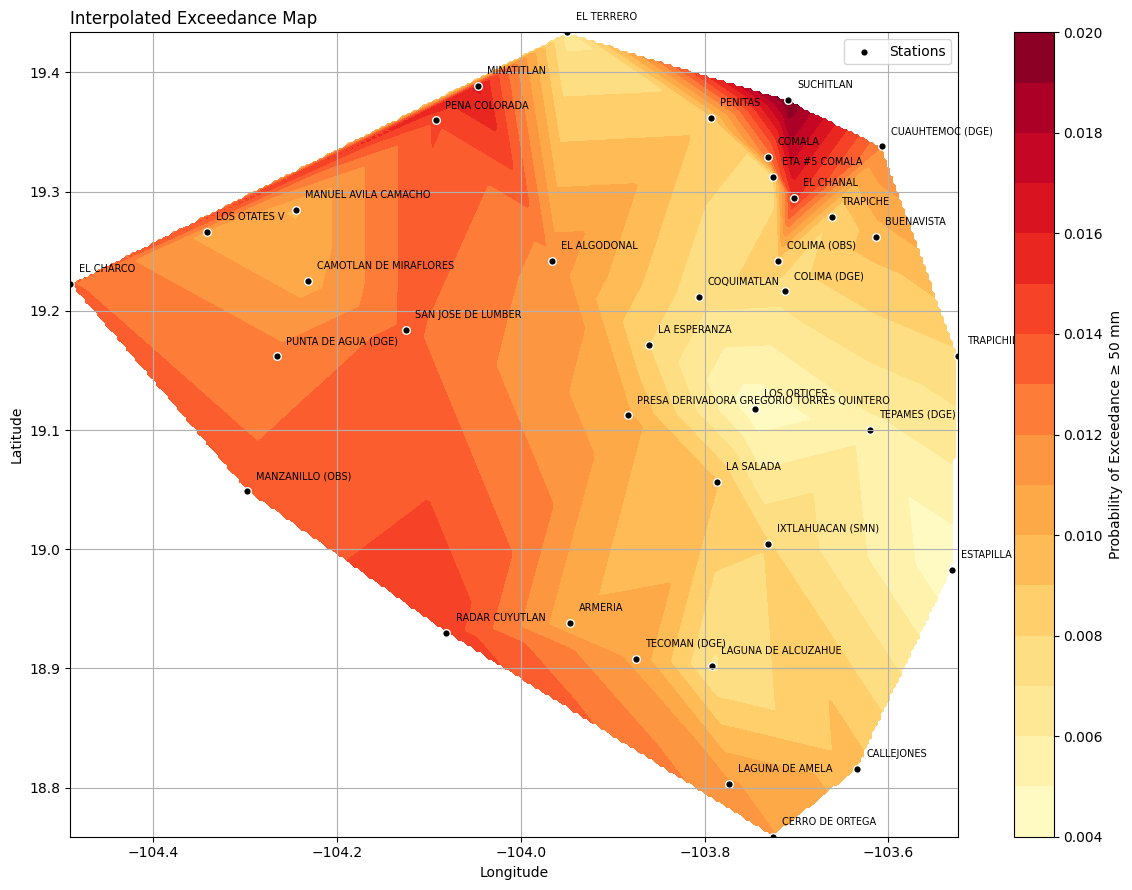

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata

df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

# Filtramos datos válidos
df = df.dropna(subset=["EXCEDENCIA_50MM"])
points = df[["LONGITUD", "LATITUD"]].values
values = df["EXCEDENCIA_50MM"].values


# Creamos una malla de puntos (grid)
grid_x, grid_y = np.mgrid[
    df["LONGITUD"].min():df["LONGITUD"].max():300j,
    df["LATITUD"].min():df["LATITUD"].max():300j
]

# Interpolación griddata (tipo IDW lineal)
grid_z = griddata(points, values, (grid_x, grid_y), method="linear")

# Visualización del mapa
plt.figure(figsize=(12, 9))
contour = plt.contourf(grid_x, grid_y, grid_z, levels=15, cmap="YlOrRd") # mapa de valor continuo (contour plot) "y10rRd" muestra zonas con más o menos probabilidad
plt.colorbar(contour, label="Probability of Exceedance ≥ 50 mm")

# Agregamos las estaciones al mapa.

plt.scatter(df["LONGITUD"], df["LATITUD"], c="black", s=30, edgecolors="white", label="Stations")

# Etiquetas de nombres
for i, row in df.iterrows():
    plt.text(row["LONGITUD"] + 0.01, row["LATITUD"] + 0.01, row["NOMBRE"], fontsize=7, color='black')

plt.title("Interpolated Exceedance Map", loc="left")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Ampliamos más el mapa para que las etiquetas se vean de una mejor manera


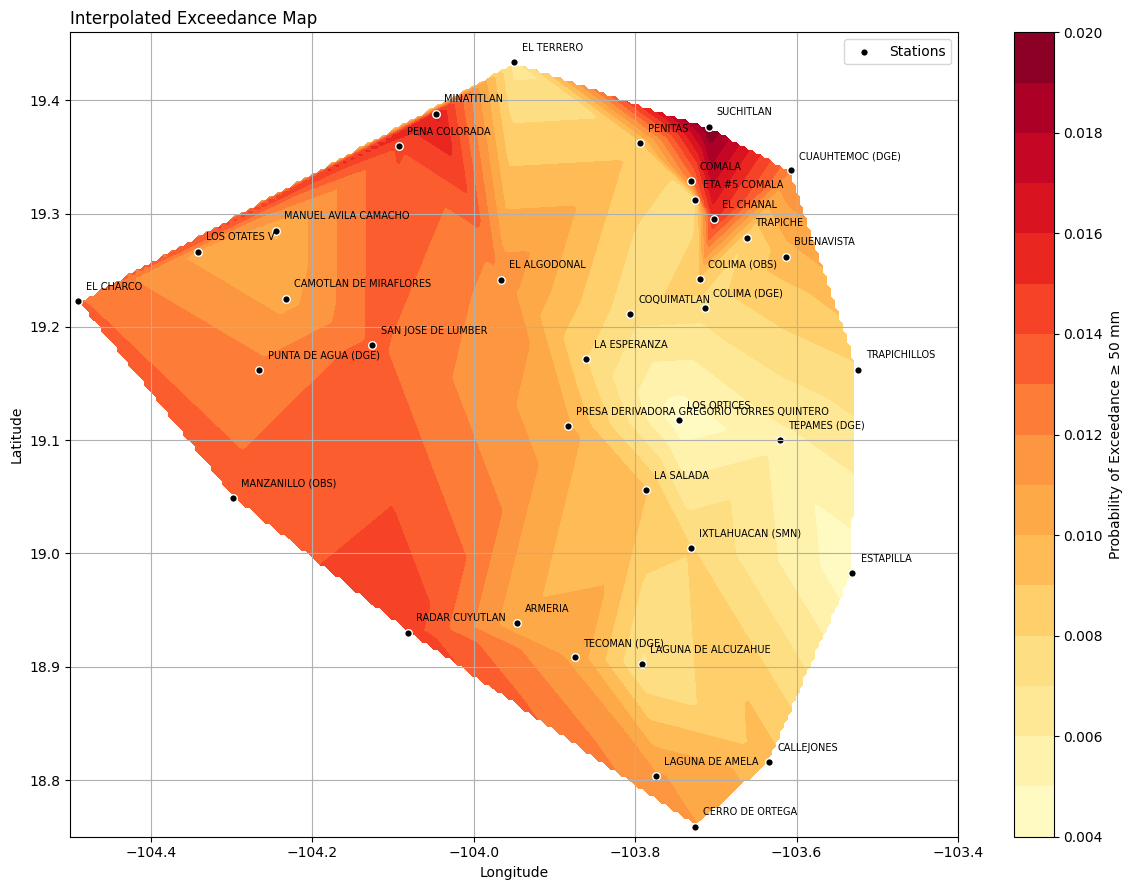

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata

df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

# Filtramos datos válidos
df = df.dropna(subset=["EXCEDENCIA_50MM"])
points = df[["LONGITUD", "LATITUD"]].values
values = df["EXCEDENCIA_50MM"].values

# Creamos una malla de puntos (grid) — (IGUAL QUE TU CÓDIGO ORIGINAL)
grid_x, grid_y = np.mgrid[
    df["LONGITUD"].min():df["LONGITUD"].max():200j,
    df["LATITUD"].min():df["LATITUD"].max():200j
]

# Interpolación griddata (tipo IDW lineal)
grid_z = griddata(points, values, (grid_x, grid_y), method="linear")

# Visualización del mapa
plt.figure(figsize=(12, 9))
contour = plt.contourf(grid_x, grid_y, grid_z, levels=15, cmap="YlOrRd")
plt.colorbar(contour, label="Probability of Exceedance ≥ 50 mm")

# Agregamos las estaciones al mapa.
plt.scatter(df["LONGITUD"], df["LATITUD"], c="black", s=30, edgecolors="white", label="Stations")

# Etiquetas de nombres
for i, row in df.iterrows():
    plt.text(row["LONGITUD"] + 0.01, row["LATITUD"] + 0.01, row["NOMBRE"],
             fontsize=7, color='black', clip_on=True)

plt.title("Interpolated Exceedance Map", loc="left")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

# ✅ SOLO LO QUE PEDISTE (límites)
plt.xlim(-104.5, -103.4)
plt.ylim(18.75, 19.46)

plt.tight_layout()
plt.show()


# Mapa más grande

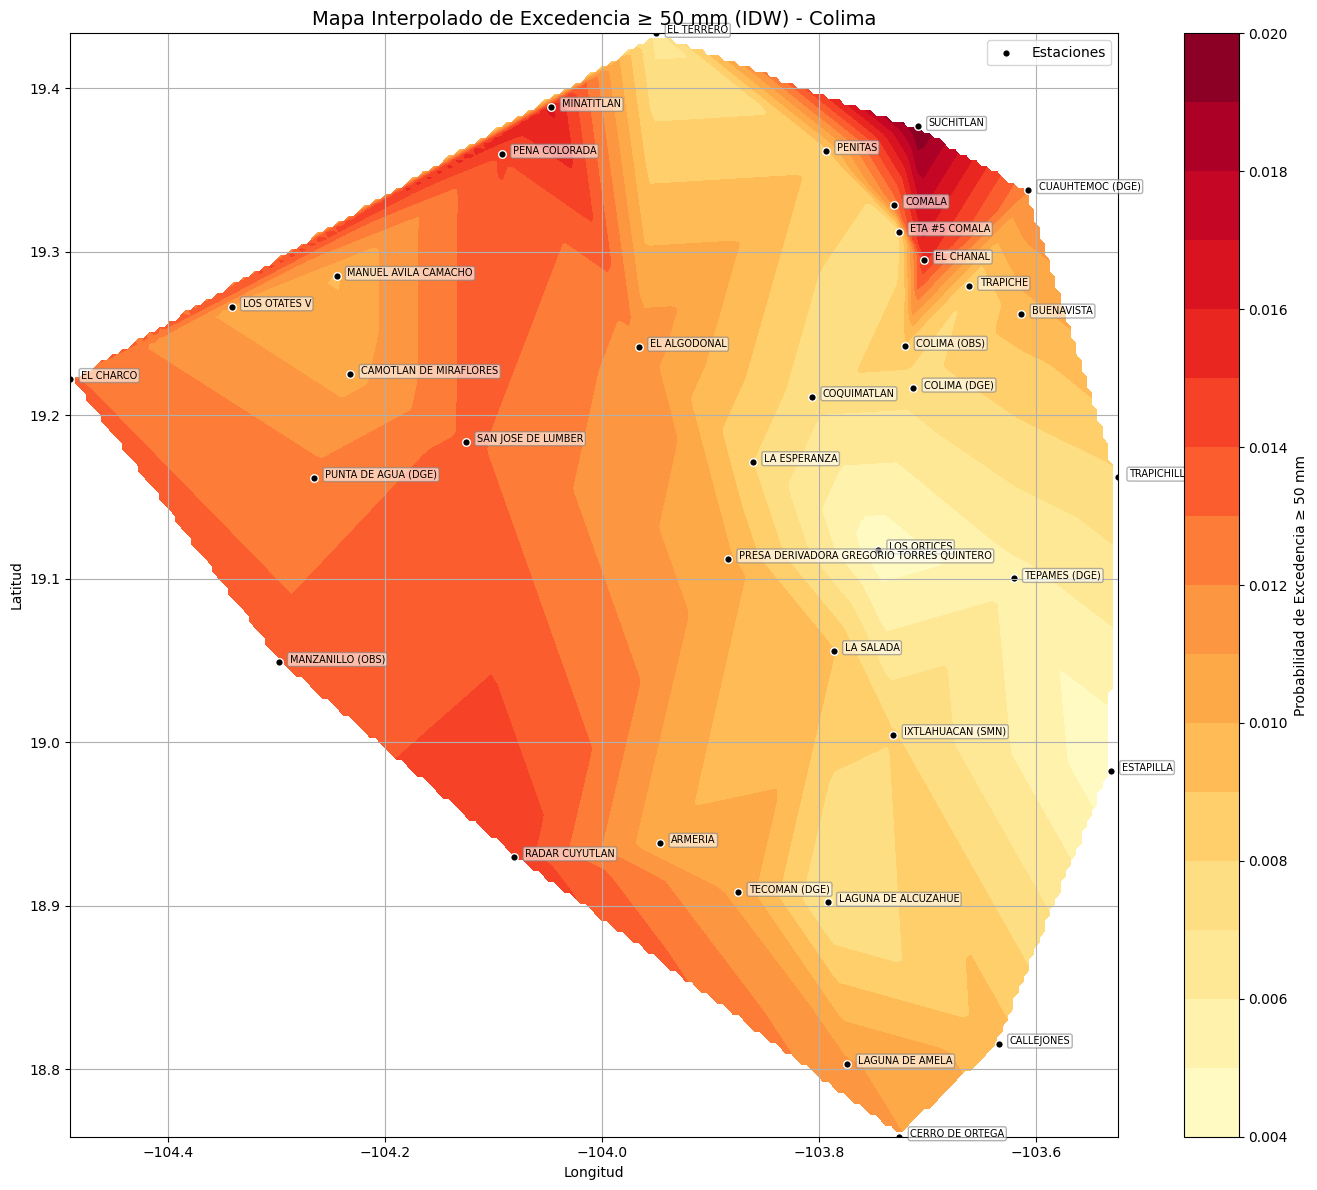

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata

df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

# Filtramos datos válidos
df = df.dropna(subset=["EXCEDENCIA_50MM"])
points = df[["LONGITUD", "LATITUD"]].values
values = df["EXCEDENCIA_50MM"].values

# Definir un margen manual más amplio (aprox. ±0.2 grados)
lon_min = df["LONGITUD"].min() - 0.2
lon_max = df["LONGITUD"].max() + 0.2
lat_min = df["LATITUD"].min() - 0.2
lat_max = df["LATITUD"].max() + 0.2

# Creamos una malla de puntos (grid)
grid_x, grid_y = np.mgrid[
    df["LONGITUD"].min():df["LONGITUD"].max():200j,
    df["LATITUD"].min():df["LATITUD"].max():200j
]

# Interpolación griddata (tipo IDW lineal)
grid_z = griddata(points, values, (grid_x, grid_y), method="linear")

# Visualización del mapa
plt.figure(figsize=(14, 12))
contour = plt.contourf(grid_x, grid_y, grid_z, levels=15, cmap="YlOrRd") # mapa de valor continuo (contour plot) "y10rRd" muestra zonas con más o menos probabilidad
plt.colorbar(contour, label="Probabilidad de Excedencia ≥ 50 mm")

# Agregamos las estaciones al mapa.

plt.scatter(df["LONGITUD"], df["LATITUD"], c="black", s=30, edgecolors="white", label="Estaciones")

# Etiquetas de nombres
for i, row in df.iterrows():
    plt.text(
        row["LONGITUD"] + 0.01, row["LATITUD"],
        row["NOMBRE"], fontsize=7,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.6)
    )

plt.title("Mapa Interpolado de Excedencia ≥ 50 mm (IDW) - Colima", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



##Interpolación CUBIC

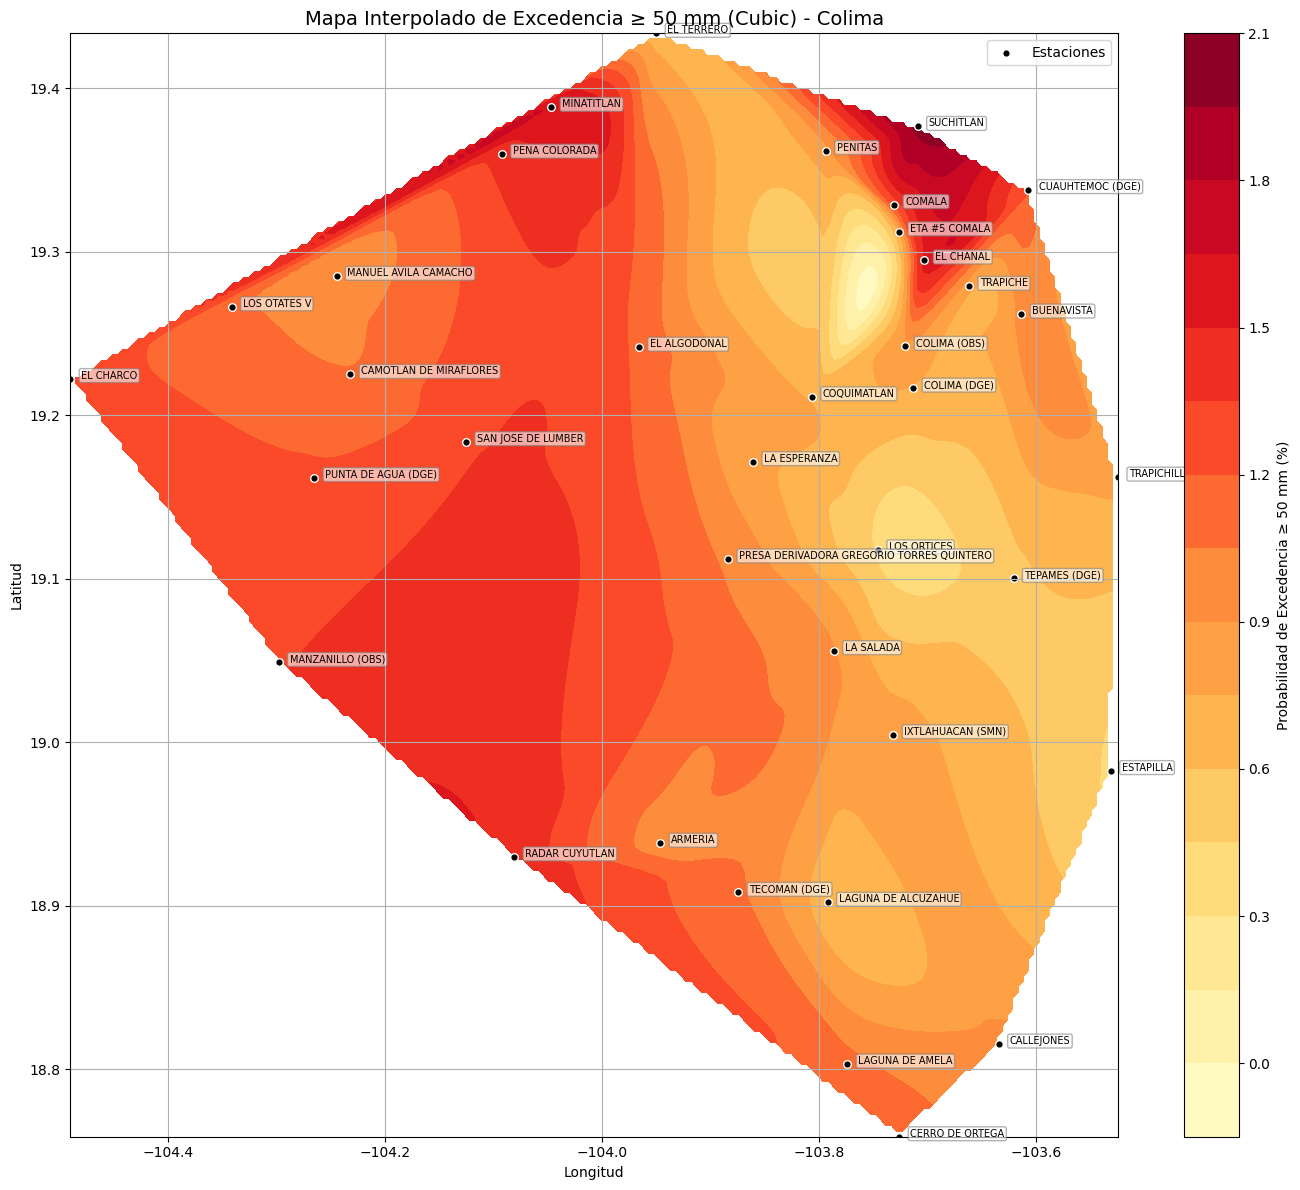

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

# Filtrar datos válidos
df = df.dropna(subset=["EXCEDENCIA_50MM"])

# Convertir a porcentaje
df["EXCEDENCIA_50MM"] = df["EXCEDENCIA_50MM"] * 100

points = df[["LONGITUD", "LATITUD"]].values
values = df["EXCEDENCIA_50MM"].values

# Definir un margen manual más amplio
lon_min = df["LONGITUD"].min() - 0.2
lon_max = df["LONGITUD"].max() + 0.2
lat_min = df["LATITUD"].min() - 0.2
lat_max = df["LATITUD"].max() + 0.2

# Crear malla de puntos
grid_x, grid_y = np.mgrid[
    df["LONGITUD"].min():df["LONGITUD"].max():200j,
    df["LATITUD"].min():df["LATITUD"].max():200j
]

# Interpolación con cubic
grid_z = griddata(points, values, (grid_x, grid_y), method="cubic")

# Visualización
plt.figure(figsize=(14, 12))
contour = plt.contourf(grid_x, grid_y, grid_z, levels=15, cmap="YlOrRd")
plt.colorbar(contour, label="Probabilidad de Excedencia ≥ 50 mm (%)")

# Puntos de estaciones
plt.scatter(df["LONGITUD"], df["LATITUD"], c="black", s=30, edgecolors="white", label="Estaciones")

# Etiquetas
for i, row in df.iterrows():
    plt.text(
        row["LONGITUD"] + 0.01, row["LATITUD"],
        row["NOMBRE"], fontsize=7,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.6)
    )

plt.title("Mapa Interpolado de Excedencia ≥ 50 mm (Cubic) - Colima", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


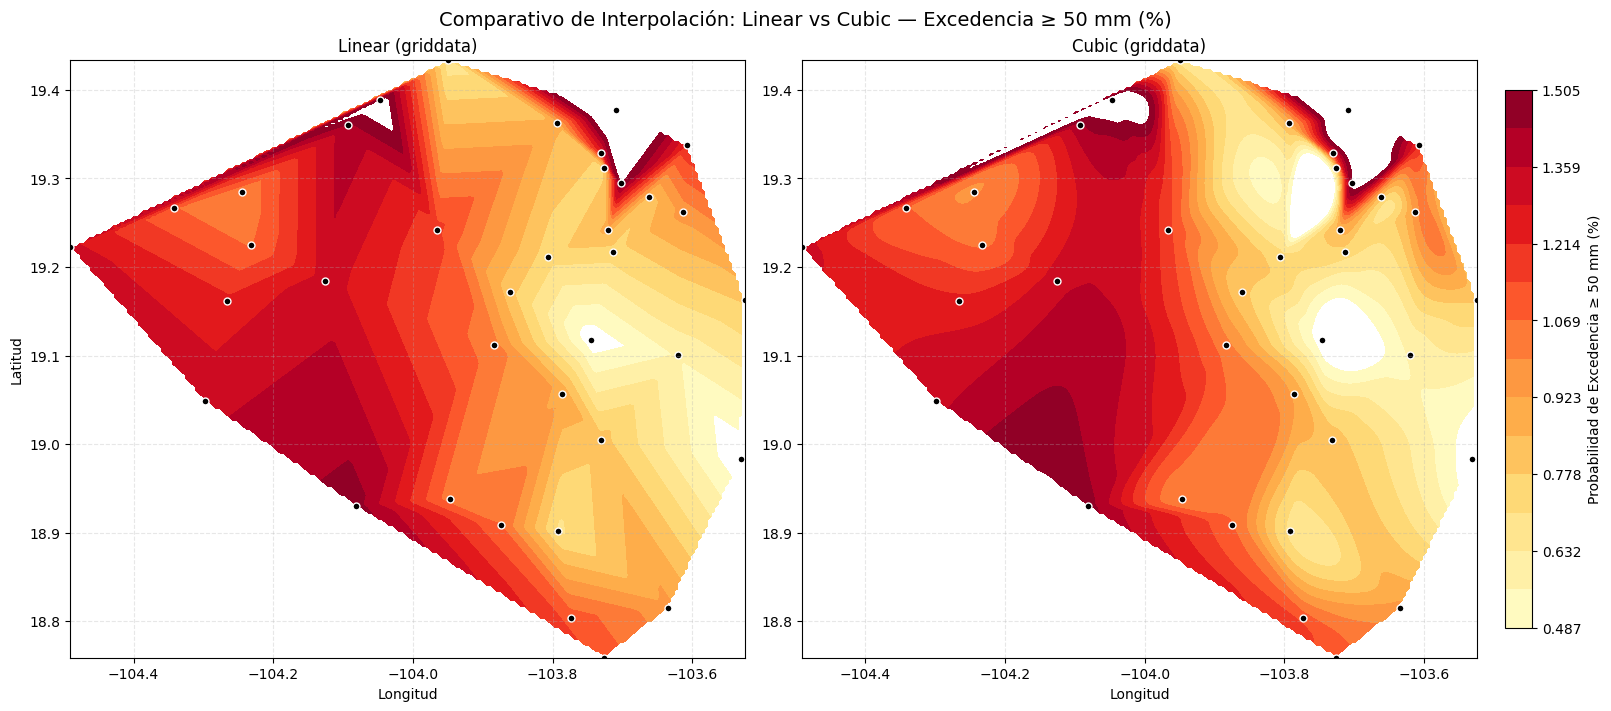

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv")

df = df.dropna(subset=["EXCEDENCIA_50MM"]).copy()
# Convertir a porcentaje
df["EXCEDENCIA_50MM"] = df["EXCEDENCIA_50MM"] * 100

points = df[["LONGITUD", "LATITUD"]].values
values = df["EXCEDENCIA_50MM"].values


# Malla común
GX, GY = np.mgrid[
    df["LONGITUD"].min():df["LONGITUD"].max():200j,
    df["LATITUD"].min():df["LATITUD"].max():200j
]

# Interpolaciones
Z_lin   = griddata(points, values, (GX, GY), method="linear")
Z_cubic = griddata(points, values, (GX, GY), method="cubic")

# Rellenar NaN fuera del casco convexo con "nearest" para que el colorbar sea comparable
FILL_OUTSIDE = False
if FILL_OUTSIDE:
    Z_near = griddata(points, values, (GX, GY), method="nearest")
    Z_lin   = np.where(np.isnan(Z_lin),   Z_near, Z_lin)
    Z_cubic = np.where(np.isnan(Z_cubic), Z_near, Z_cubic)

# Escala común (evita que cada panel "autoescale")
# Usa percentiles para robustez ante outliers
vmin = np.nanpercentile([Z_lin, Z_cubic], 2)
vmax = np.nanpercentile([Z_lin, Z_cubic], 98)
levels = np.linspace(vmin, vmax, 15)

# === Ploteo comparativo ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

im0 = axes[0].contourf(GX, GY, Z_lin, levels=levels, cmap="YlOrRd")
axes[0].scatter(df["LONGITUD"], df["LATITUD"], c="black", s=25, edgecolors="white")
axes[0].set_title("Linear (griddata)")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].grid(True, linestyle="--", alpha=0.3)

im1 = axes[1].contourf(GX, GY, Z_cubic, levels=levels, cmap="YlOrRd")
axes[1].scatter(df["LONGITUD"], df["LATITUD"], c="black", s=25, edgecolors="white")
axes[1].set_title("Cubic (griddata)")
axes[1].set_xlabel("Longitud")
axes[1].grid(True, linestyle="--", alpha=0.3)

# Colorbar común a ambos subplots
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label("Probabilidad de Excedencia ≥ 50 mm (%)")

fig.suptitle("Comparativo de Interpolación: Linear vs Cubic — Excedencia ≥ 50 mm (%)", fontsize=14)
plt.show()

In [ ]:
print(df.head())

   CLAVE                  NOMBRE  ESTADO    LATITUD    LONGITUD  \
0   6001                 ARMERIA  COLIMA  18.938333 -103.946389   
1   6002              BUENAVISTA  COLIMA  19.261944 -103.613333   
2   6003              CALLEJONES  COLIMA  18.815556 -103.634167   
3   6004  CAMOTLAN DE MIRAFLORES  COLIMA  19.225000 -104.232222   
4   6005         CERRO DE ORTEGA  COLIMA  18.758889 -103.725833   

   EXCEDENCIA_50MM  
0         1.021926  
1         0.951252  
2         0.943189  
3         1.059726  
4         1.105366  


#VAMOS A VISUALIZAR AHORA EN QGIS.


In [ ]:
!pip install rasterio shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 79.3 MB/s eta 0:00:00


In [ ]:
# ========= Exportar GeoTIFF (QGIS) con malla exclusiva y alineada =========
import os
import numpy as np
import rasterio
from rasterio.transform import from_origin
from scipy.interpolate import griddata

# 1) Extent para el TIFF (con margen para cubrir municipios periféricos)
margin = 0.25  # aumenta a 0.35–0.4 si aún falta algo en los bordes
lon_min_e = df["LONGITUD"].min() - margin
lon_max_e = df["LONGITUD"].max() + margin
lat_min_e = df["LATITUD"].min() - margin
lat_max_e = df["LATITUD"].max() + margin

# 2) Resolución y tamaño del grid de exportación (independiente del de la figura)
nx_exp, ny_exp = 400, 400   # sube a 600x600 si quieres más detalle
gx = np.linspace(lon_min_e, lon_max_e, nx_exp)  # centros en X (longitud)
gy = np.linspace(lat_min_e, lat_max_e, ny_exp)  # centros en Y (latitud)

# Malla de exportación explícita (XY correcto)
grid_x_exp, grid_y_exp = np.meshgrid(gx, gy, indexing="xy")  # shapes: (ny_exp, nx_exp)

# 3) Interpolación LINEAR y relleno con NEAREST sólo donde linear es NaN (bordes)
pts = df[["LONGITUD", "LATITUD"]].values
vals = df["EXCEDENCIA_50MM"].values  # en la figura no multiplicas por 100; mantenemos lo mismo aquí

grid_lin = griddata(pts, vals, (grid_x_exp, grid_y_exp), method="linear")
grid_near = griddata(pts, vals, (grid_x_exp, grid_y_exp), method="nearest")
grid_filled = np.where(np.isnan(grid_lin), grid_near, grid_lin)

# 4) Preparar array para rasterio (rasterio espera filas=Y (lat), cols=X (lon))
arr = grid_filled.astype("float32")              # shape: (ny_exp, nx_exp), ya correcto (NO transponer)
nodata = -9999.0
arr_out = np.where(np.isnan(arr), nodata, arr)
arr_out = np.ascontiguousarray(arr_out)

# 5) Shift de media celda para pasar de centros -> esquina sup-izq
dx = gx[1] - gx[0]
dy = gy[1] - gy[0]
west_corner  = gx.min() - dx/2.0
north_corner = gy.max() + dy/2.0
transform = from_origin(west_corner, north_corner, dx, dy)

# 6) Perfil mínimo y escritura
profile = {
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": nodata,
    "width": int(arr_out.shape[1]),   # nx_exp
    "height": int(arr_out.shape[0]),  # ny_exp
    "count": 1,
    "crs": "EPSG:4326",
    "transform": transform
}

out_tif = "excedencia_linear_colima_full_aligned.tif"
for extra in ("", ".aux.xml"):
    try:
        os.remove(out_tif + extra)
    except FileNotFoundError:
        pass

with rasterio.open(out_tif, "w", **profile) as dst:
    dst.write(arr_out, 1)

print(f"GeoTIFF alineado y completo → {out_tif} (EPSG:4326). Cárgalo en QGIS.")
# ========= FIN BLOQUE =========



GeoTIFF alineado y completo → excedencia_linear_colima_full_aligned.tif (EPSG:4326). Cárgalo en QGIS.


#Intervalos de confianza (95%) con booleados aleatorios y SciPy

Para cada estación, se genera ensayos Bernoulli con probabilidad igual a la excedencia observada.

Se aplica scipy.stats.bootstrap a la media (proporción) para obtener el IC 95% por estación (método BCa).

Se Interpola con cubic las superficies P_LOW, P_MEAN y P_HIGH.

Muestra dos paneles: estimación central (%) y ancho del intervalo (pp) como mapa de incertidumbre.

/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


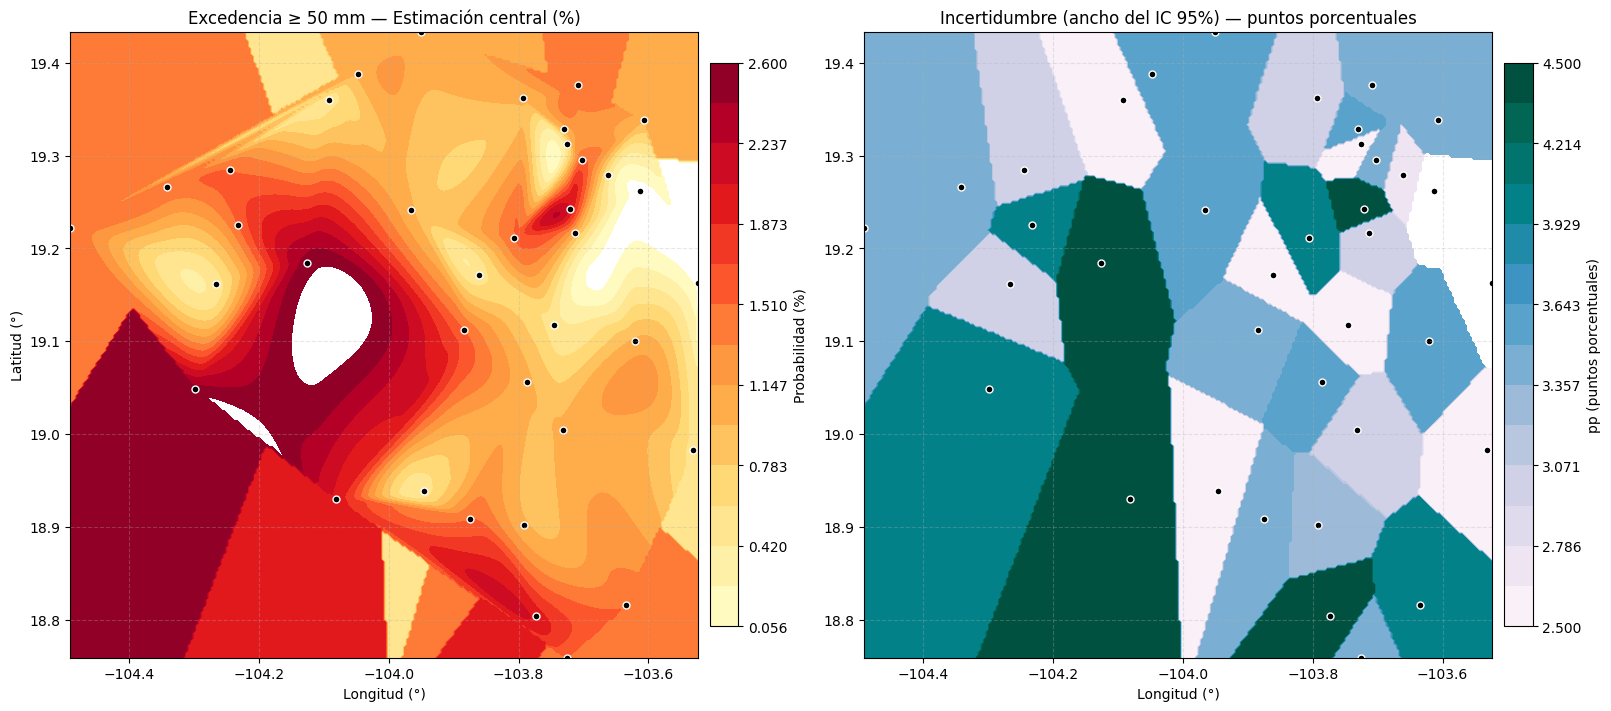

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.stats import bootstrap

CSV = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/excedencia_colima.csv"
COL_LON = "LONGITUD"
COL_LAT = "LATITUD"
COL_P = "EXCEDENCIA_50MM"

# Parámetros de simulación
N_BERNOULLI = 200   # número de ensayos Bernoulli por estación
N_BOOT = 1000       # número de remuestreos bootstrap
CONF_LEVEL = 0.95

# Datos
df = pd.read_csv(CSV)
df = df.dropna(subset=[COL_LON, COL_LAT, COL_P]).copy()

# Aseguramos que la prob. esté en 0-1 (si ya está en 0-1, esta línea no cambia nada)
# Si la tenías en porcentaje previamente, descomenta:
# df[COL_P] = df[COL_P].astype(float) / 100.0

# === Función: IC por estación vía booleados + bootstrap ===
def station_ci(p, n_trials=N_BERNOULLI, n_boot=N_BOOT, conf=CONF_LEVEL, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    # Ensayos Bernoulli ~ Binomial(n=1, p)
    sample = rng.binomial(1, float(p), size=n_trials)
    # Bootstrap sobre la media (proporción)
    res = bootstrap((sample,), np.mean, confidence_level=conf, n_resamples=n_boot, method="BCa")
    low, high = res.confidence_interval.low, res.confidence_interval.high
    return sample.mean(), low, high

# === Calcular IC por estación ===
rng = np.random.default_rng(42)
est_means = []
est_low = []
est_high = []
for p in df[COL_P].astype(float).values:
    m, lo, hi = station_ci(p, rng=rng)
    est_means.append(m)
    est_low.append(lo)
    est_high.append(hi)

df["P_MEAN"] = np.array(est_means)
df["P_LOW"]  = np.array(est_low)
df["P_HIGH"] = np.array(est_high)

# Convertimos a porcentaje para gráficos
for c in ["P_MEAN", "P_LOW", "P_HIGH"]:
    df[c] = df[c] * 100.0

# === Malla (común) ===
GX, GY = np.mgrid[
    df[COL_LON].min():df[COL_LON].max():250j,
    df[COL_LAT].min():df[COL_LAT].max():250j
]

# === Interpolación cubic de cada superficie ===
pts = df[[COL_LON, COL_LAT]].values
Z_mean = griddata(pts, df["P_MEAN"].values, (GX, GY), method="cubic")
Z_low  = griddata(pts, df["P_LOW" ].values, (GX, GY), method="cubic")
Z_high = griddata(pts, df["P_HIGH"].values, (GX, GY), method="cubic")

# Relleno opcional (nearest) fuera de casco convexo
Z_near_mean = griddata(pts, df["P_MEAN"].values, (GX, GY), method="nearest")
Z_near_low  = griddata(pts, df["P_LOW" ].values, (GX, GY), method="nearest")
Z_near_high = griddata(pts, df["P_HIGH"].values, (GX, GY), method="nearest")

Z_mean = np.where(np.isnan(Z_mean), Z_near_mean, Z_mean)
Z_low  = np.where(np.isnan(Z_low ), Z_near_low , Z_low )
Z_high = np.where(np.isnan(Z_high), Z_near_high, Z_high)

# === Derivados ===
Z_width = Z_high - Z_low   # ancho del IC (pp)

# === Visualización: Estimación central y Ancho del IC ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Panel A: estimación central
levels_m = np.linspace(np.nanpercentile(Z_mean, 2), np.nanpercentile(Z_mean, 98), 15)
im0 = axes[0].contourf(GX, GY, Z_mean, levels=levels_m, cmap="YlOrRd")
axes[0].scatter(df[COL_LON], df[COL_LAT], c="black", s=25, edgecolors="white", label="Estaciones")
axes[0].set_title("Excedencia ≥ 50 mm — Estimación central (%)")
axes[0].set_xlabel("Longitud (°)")
axes[0].set_ylabel("Latitud (°)")
axes[0].grid(True, linestyle='--', alpha=0.3)
cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.9, pad=0.02)
cb0.set_label("Probabilidad (%)")

# Panel B: ancho del intervalo (incertidumbre)
levels_w = np.linspace(np.nanpercentile(Z_width, 2), np.nanpercentile(Z_width, 98), 15)
im1 = axes[1].contourf(GX, GY, Z_width, levels=levels_w, cmap="PuBuGn")
axes[1].scatter(df[COL_LON], df[COL_LAT], c="black", s=25, edgecolors="white")
axes[1].set_title(f"Incertidumbre (ancho del IC {int(CONF_LEVEL*100)}%) — puntos porcentuales")
axes[1].set_xlabel("Longitud (°)")
axes[1].grid(True, linestyle='--', alpha=0.3)
cb1 = fig.colorbar(im1, ax=axes[1], shrink=0.9, pad=0.02)
cb1.set_label("pp (puntos porcentuales)")

##SUSTAX ANALISIS

Codigo original de sustax

In [ ]:
# === load_sustax_file(...)
def load_sustax_file(csv_stx, return_pandas_df = True, return_metadata = False):
    """
    Pull Sustax CSV data to Python's IDE as numpy arrays or as panda dataframes

    Parameters:
    ----------
        - csv_stx: Str. or Path obj. Full file name pointing to Sustax CSV
        - return_pandas_df: Bool. Use bool(True) to get outputs as Pandas obj.
        - return_metadata: Bool. Use bool(True) to get CSV metadata

    Returns:
    -------
        Returns two, three or four objects depending on `return_pandas_df` and
        `return_metadata` parameters:
            1. Climate data: All `Data requested` field from the CSV file
            2. Accuracy metrics: All `Metrics requested` field from the CSV file
            3. Climate data Time Stamps: All timesteps in `Data requested` field
            4. Metadata: Dictionary object containg all the CSV metadata
        The climate data and accuracy metrics can be returned as dictionaries
        with arrays or as Pandas dataframe
        If `return_pandas_df` is requested, Time Stamps are merged with the
        climate data automatically

    External packages required:
    --------------------------
        - Numpy
        - Pandas
    """

    # Imports "inside" for compactness. We encourage to place all imports
    # at the beginning of your module / script file
    import csv
    import decimal
    import numpy as np
    import pandas as pd
    from datetime import datetime
    def _isfloat(string):
        try:
            decimal.Decimal(string)
            return True
        except decimal.InvalidOperation:
            return False

    with open(csv_stx, 'r', encoding = None) as fobj:
        data = csv.reader(fobj, delimiter = ',')
        data = [i for i in data]
    if return_metadata:
        mt = {}
        for r in data:
            mt["creation_date"] = data[1][1]
            if any(['longitude' in h.lower() for h in r]):
                mt["lon"] = [float(rr) for rr in r if _isfloat(rr)][0]
            if any(['latitude' in h.lower() for h in r]):
                mt["lat"] = [float(rr) for rr in r if _isfloat(rr)][0]
            if any(['soil variables' in h.lower() for h in r]):
                idx_loc = [c for c in range(len(data)) if 'Soil variables:' in data[c]][0]
                mt["soil_data"] = {}
                for c in range(1, len(r)):
                    if r[c]:
                        mt["soil_data"].update({data[idx_loc][c]:data[idx_loc+1][c]})

    # Check if daily or monthly dataset, get the whole string
    dts_type = [d for d in data if (len(d) > 0) and (d[0] == 'Dataset:')][0][1]
    # Get climate data
    # Four rows below to get the metric values
    idx_data = [c for c in range(len(data))\
                if 'Data requested:' in data[c]][0] + 4
    all_data = data[idx_data:]
    all_data_vars = data[idx_data-3]
    all_data_scenarios = data[idx_data-2]
    if return_metadata:
        mt["var_us"] = [r for r in data[idx_data-1] if r]
        mt["var_scs"] = [r for r in data[idx_data-2] if r and (r.lower() != 'time')]
        mt["var_nm"] = [r.split('-')[0] for r in data[idx_data-3] if r]
        try:
            # In this case returns the unique long name
            idx_long = [c for c in range(len(data)) if 'Climate variables long name:' in data[c]][0]
            mt["var_l_nm"] = data[idx_long][1].split(',')
        except (IndexError, TypeError):
            pass
    # Get metrics data
    if [d for d in data if (len(d) > 0) and\
                           ('Metric variables:' in d)][0][1] != '':
        # Two rows below to get the metric values
        # Five row up to get to the last metric
        idx_metrics = [c for c in range(len(data))\
                       if 'Metrics requested:' in data[c]][0] + 2
        all_metrics = data[idx_metrics:idx_data - 5]
    else:
        all_metrics = {}
    dt_metrics = {}
    for r in all_metrics:
        metric_nm = r[0].split(' - ')[0]
        var_nm = r[0].split(' - ')[1]
        if var_nm not in dt_metrics:
            dt_metrics.update({var_nm:{}})
        dt_metrics[var_nm].update({metric_nm:{}})
        for c in range(1, len(r)):
            if _isfloat(r[c]):
                dt_metrics[var_nm][metric_nm][all_data_scenarios[c]] = float(r[c])

    # Get climate payload data
    dt = {}
    for c in range(len(all_data_vars)):
        if all_data_vars[c] != '':
            dt.setdefault(all_data_vars[c],{}).update({all_data_scenarios[c]:[]})

    # Load all data to local variables
    time = []
    for r in all_data:
        for c in range(len(r)):
            if ("SSP" in all_data_scenarios[c]) or ("ERA" in all_data_scenarios[c]):
                dt[all_data_vars[c]][all_data_scenarios[c]].append(float(r[c]) if r[c]!='' else float('NaN'))
        time.append(datetime.strptime(r[0], '%Y/%m' if 'monthly' in dts_type.lower()\
                                                    else "%Y/%m/%d"))
    # Payload data to array
    time = np.array(time, dtype = f'datetime64[{"M" if "monthly" in dts_type.lower() else "D"}]')
    dt = {k: {s: np.asarray(dt[k][s]) for s in dt[k]} for k in dt}
    if return_pandas_df:
        all_dfs = [pd.Series({d: v for d, v in zip(time, dt[var][s])}).to_frame(name = f"{var} [{s}]")\
                   for var in dt for s in dt[var]]
        df_vals = all_dfs[0].join(all_dfs[1:])
        # Return empty DF if no metrics
        all_dfs = [pd.Series({v: dt_metrics[var][s][v] for v in dt_metrics[var][s]}).to_frame(name = f"{var} [{s}]")\
                   for var in dt_metrics for s in dt_metrics[var]]
        # Avoid empty metrics if csv does not contain them
        df_metrics = all_dfs[0].join(all_dfs[1:]) if all_dfs else pd.DataFrame()

        if return_metadata:
            return df_vals, df_metrics, mt
        else:
            return df_vals, df_metrics
    else:
        if return_metadata:
            return dt, dt_metrics, time, mt
        else:
            return dt, dt_metrics, time


Analisis de estaciones con sustax codigo modificado.

In [ ]:
# === load_sustax_file(...) tomado literalmente de Sustax Docs ===
def load_sustax_file(csv_stx, return_pandas_df = True, return_metadata = False):
    """
    Pull Sustax CSV data to Python's IDE as numpy arrays or as panda dataframes

    Parameters:
    ----------
        - csv_stx: Str. or Path obj. Full file name pointing to Sustax CSV
        - return_pandas_df: Bool. Use bool(True) to get outputs as Pandas obj.
        - return_metadata: Bool. Use bool(True) to get CSV metadata

    Returns:
    -------
        Returns two, three or four objects depending on `return_pandas_df` and
        `return_metadata` parameters:
            1. Climate data: All `Data requested` field from the CSV file
            2. Accuracy metrics: All `Metrics requested` field from the CSV file
            3. Climate data Time Stamps: All timesteps in `Data requested` field
            4. Metadata: Dictionary object containg all the CSV metadata
        The climate data and accuracy metrics can be returned as dictionaries
        with arrays or as Pandas dataframe
        If `return_pandas_df` is requested, Time Stamps are merged with the
        climate data automatically

    External packages required:
    --------------------------
        - Numpy
        - Pandas
    """

    # Imports "inside" for compactness. We encourage to place all imports
    # at the beginning of your module / script file
    import csv
    import decimal
    import numpy as np
    import pandas as pd
    from datetime import datetime
    def _isfloat(string):
        try:
            decimal.Decimal(string)
            return True
        except decimal.InvalidOperation:
            return False

    with open(csv_stx, 'r', encoding = None) as fobj:
        data = csv.reader(fobj, delimiter = ',')
        data = [i for i in data]
    if return_metadata:
        mt = {}
        for r in data:
            mt["creation_date"] = data[1][1]
            if any(['longitude' in h.lower() for h in r]):
                mt["lon"] = [float(rr) for rr in r if _isfloat(rr)][0]
            if any(['latitude' in h.lower() for h in r]):
                mt["lat"] = [float(rr) for rr in r if _isfloat(rr)][0]
            if any(['soil variables' in h.lower() for h in r]):
                idx_loc = [c for c in range(len(data)) if 'Soil variables:' in data[c]][0]
                mt["soil_data"] = {}
                for c in range(1, len(r)):
                    if r[c]:
                        mt["soil_data"].update({data[idx_loc][c]:data[idx_loc+1][c]})

    # Check if daily or monthly dataset, get the whole string
    dts_type = [d for d in data if (len(d) > 0) and (d[0] == 'Dataset:')][0][1]
    # Get climate data
    # Four rows below to get the metric values
    idx_data = [c for c in range(len(data))\
                if 'Data requested:' in data[c]][0] + 4
    all_data = data[idx_data:]
    all_data_vars = data[idx_data-3]
    all_data_scenarios = data[idx_data-2]
    if return_metadata:
        mt["var_us"] = [r for r in data[idx_data-1] if r]
        mt["var_scs"] = [r for r in data[idx_data-2] if r and (r.lower() != 'time')]
        mt["var_nm"] = [r.split('-')[0] for r in data[idx_data-3] if r]
        try:
            # In this case returns the unique long name
            idx_long = [c for c in range(len(data)) if 'Climate variables long name:' in data[c]][0]
            mt["var_l_nm"] = data[idx_long][1].split(',')
        except (IndexError, TypeError):
            pass
    # Get metrics data
    if [d for d in data if (len(d) > 0) and\
                           ('Metric variables:' in d)][0][1] != '':
        # Two rows below to get the metric values
        # Five row up to get to the last metric
        idx_metrics = [c for c in range(len(data))\
                       if 'Metrics requested:' in data[c]][0] + 2
        all_metrics = data[idx_metrics:idx_data - 5]
    else:
        all_metrics = {}
    dt_metrics = {}
    for r in all_metrics:
        metric_nm = r[0].split(' - ')[0]
        var_nm = r[0].split(' - ')[1]
        if var_nm not in dt_metrics:
            dt_metrics.update({var_nm:{}})
        dt_metrics[var_nm].update({metric_nm:{}})
        for c in range(1, len(r)):
            if _isfloat(r[c]):
                dt_metrics[var_nm][metric_nm][all_data_scenarios[c]] = float(r[c])

    # Get climate payload data
    dt = {}
    for c in range(len(all_data_vars)):
        if all_data_vars[c] != '':
            dt.setdefault(all_data_vars[c],{}).update({all_data_scenarios[c]:[]})

    # Load all data to local variables
    time = []
    for r in all_data:
        for c in range(len(r)):
            if ("SSP" in all_data_scenarios[c]) or ("ERA" in all_data_scenarios[c]):
                dt[all_data_vars[c]][all_data_scenarios[c]].append(float(r[c]) if r[c]!='' else float('NaN'))
        time.append(datetime.strptime(r[0], '%Y/%m' if 'monthly' in dts_type.lower()\
                                                    else "%Y/%m/%d"))
    # Payload data to array
    time = np.array(time, dtype = f'datetime64[{"M" if "monthly" in dts_type.lower() else "D"}]')
    dt = {k: {s: np.asarray(dt[k][s]) for s in dt[k]} for k in dt}
    if return_pandas_df:
        all_dfs = [pd.Series({d: v for d, v in zip(time, dt[var][s])}).to_frame(name = f"{var} [{s}]")\
                   for var in dt for s in dt[var]]
        df_vals = all_dfs[0].join(all_dfs[1:])
        # Return empty DF if no metrics
        all_dfs = [pd.Series({v: dt_metrics[var][s][v] for v in dt_metrics[var][s]}).to_frame(name = f"{var} [{s}]")\
                   for var in dt_metrics for s in dt_metrics[var]]
        # Avoid empty metrics if csv does not contain them
        df_metrics = all_dfs[0].join(all_dfs[1:]) if all_dfs else pd.DataFrame()

        if return_metadata:
            return df_vals, df_metrics, mt
        else:
            return df_vals, df_metrics
    else:
        if return_metadata:
            return dt, dt_metrics, time, mt
        else:
            return dt, dt_metrics, time

#Cargamos Sustax Seguro para la corrección de fecha.
def load_sustax_file_safe(csv_stx, return_pandas_df=True, return_metadata=False):
    """
    Wrapper seguro para load_sustax_file con fechas Sustax M/D/YYYY
    """
    import csv
    import decimal
    import numpy as np
    import pandas as pd

    def _isfloat(string):
        try:
            decimal.Decimal(string)
            return True
        except decimal.InvalidOperation:
            return False

    with open(csv_stx, 'r', encoding=None) as fobj:
        data = list(csv.reader(fobj, delimiter=','))

    # Detecta dataset
    dts_type = [d for d in data if (len(d) > 0) and (d[0] == 'Dataset:')][0][1]
    idx_data = [c for c in range(len(data)) if 'Data requested:' in data[c]][0] + 4
    all_data = data[idx_data:]
    all_data_vars = data[idx_data-3]
    all_data_scenarios = data[idx_data-2]

    # Metadatos mínimos
    mt = {}
    if return_metadata:
        for r in data:
            if any(['longitude' in h.lower() for h in r]):
                mt["lon"] = [float(rr) for rr in r if _isfloat(rr)][0]
            if any(['latitude' in h.lower() for h in r]):
                mt["lat"] = [float(rr) for rr in r if _isfloat(rr)][0]

    # Payload
    dt = {}
    for c in range(len(all_data_vars)):
        if all_data_vars[c] != '':
            dt.setdefault(all_data_vars[c], {}).update({all_data_scenarios[c]: []})

    time = []
    for r in all_data:
        # Formato correcto para Sustax: Mes/Día/Año
        time.append(pd.to_datetime(r[0], format="%m/%d/%Y"))
        for c in range(len(r)):
            if ("SSP" in all_data_scenarios[c]) or ("ERA" in all_data_scenarios[c]):
                try:
                    dt[all_data_vars[c]][all_data_scenarios[c]].append(
                        float(r[c]) if r[c] != '' else np.nan
                    )
                except:
                    pass

    time = np.array(time, dtype='datetime64[D]')
    dt = {k: {s: np.asarray(dt[k][s]) for s in dt[k]} for k in dt}

    if return_pandas_df:
        dfs = [
            pd.Series({d: v for d, v in zip(time, dt[var][s])})
              .to_frame(name=f"{var} [{s}]")
            for var in dt for s in dt[var]
        ]
        df_vals = dfs[0].join(dfs[1:])
        df_metrics = pd.DataFrame()
        if return_metadata:
            return df_vals, df_metrics, mt
        else:
            return df_vals, df_metrics
    else:
        if return_metadata:
            return dt, {}, time, mt
        else:
            return dt, {}, time

csv_path = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/Sustax_Manzanillo.csv"
df_vals, df_metrics, meta = load_sustax_file_safe(
    csv_path,
    return_pandas_df=True,
    return_metadata=True
)

print("✅ Valores (df_vals):", df_vals.shape)
print("✅ Métricas (df_metrics):", df_metrics.shape)
print("✅ Metadatos (meta):", meta)


✅ Valores (df_vals): (18628, 3)
✅ Métricas (df_metrics): (0, 0)
✅ Metadatos (meta): {'lon': -104.3438, 'lat': 18.9695}


#Verificación de los datos

In [ ]:

df_vals.head()

,tp-Total Precipitation [ERA5],pr-Total Precipitation [SSP245],pr-Total Precipitation [SSP370]
1980-01-01,0.000290,0.000177,0.000093
1980-01-02,0.000067,0.001942,0.000079
1980-01-03,0.000140,0.000000,0.000000
1980-01-04,0.000000,0.000000,0.000000
1980-01-05,0.000000,0.000000,0.000000


# Conversión a mm de DF

In [ ]:
# Conversión de metros a milímetros
df_vals_mm = df_vals * 1000.0

# Verificación rápida
df_vals_mm.describe().T

,count,mean,std,min,25%,50%,75%,max
tp-Total Precipitation [ERA5],15706.0,2.560081,10.922413,0.0,0.0,0.012875,0.548840,434.520721
pr-Total Precipitation [SSP245],18628.0,2.389802,14.664892,0.0,0.0,0.012397,0.414682,430.641860
pr-Total Precipitation [SSP370],18628.0,2.370226,13.920233,0.0,0.0,0.013715,0.421745,434.520721


#Identificamos columnas de precipitación.

In [ ]:
df_vals_mm.columns.tolist()

['tp-Total Precipitation [ERA5]',
 'pr-Total Precipitation [SSP245]',
 'pr-Total Precipitation [SSP370]']

# Creación de columnas separadas para cada serie ERA5/SSP


In [ ]:
era5 = (
    df_vals_mm[["tp-Total Precipitation [ERA5]"]]
    .rename(columns={"tp-Total Precipitation [ERA5]": "pp_mm"})
    .reset_index()
    .rename(columns={"index": "date"})
)

era5.head()


,date,pp_mm
0,1980-01-01,0.289917
1,1980-01-02,0.066757
2,1980-01-03,0.139713
3,1980-01-04,0.000000
4,1980-01-05,0.000000


In [ ]:
ssp245 = (
    df_vals_mm[["pr-Total Precipitation [SSP245]"]]
    .rename(columns={"pr-Total Precipitation [SSP245]": "pp_mm"})
    .reset_index()
    .rename(columns={"index": "date"})
)

ssp245.head()

,date,pp_mm
0,1980-01-01,0.176803
1,1980-01-02,1.942147
2,1980-01-03,0.000000
3,1980-01-04,0.000000
4,1980-01-05,0.000000


In [ ]:
ssp370 = (
    df_vals_mm[["pr-Total Precipitation [SSP370]"]]
    .rename(columns={"pr-Total Precipitation [SSP370]": "pp_mm"})
    .reset_index()
    .rename(columns={"index": "date"})
)

ssp370.head()

,date,pp_mm
0,1980-01-01,0.092608
1,1980-01-02,0.079342
2,1980-01-03,0.000000
3,1980-01-04,0.000000
4,1980-01-05,0.000000


# Guardamos los escenarios por separado

In [ ]:
era5.to_csv("Sustax_Manzanillo_ERA5_mm_daily.csv", index=False)
ssp245.to_csv("Sustax_Manzanillo_SSP245_mm_daily.csv", index=False)
ssp370.to_csv("Sustax_Manzanillo_SSP370_mm_daily.csv", index=False)


#guardar escenarios Sustax para todos los puntos.

In [ ]:
import os
import glob
import re
import pandas as pd
import numpy as np

# =====================================================
# CONFIGURACIÓN
# =====================================================
PATH_SUSTAX_FOLDER = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax"

OUT_LONG = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_LONG_MM")
OUT_SCEN = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_SCENARIOS_MM")

os.makedirs(OUT_LONG, exist_ok=True)
os.makedirs(OUT_SCEN, exist_ok=True)

# =====================================================
# HELPERS
# =====================================================
def split_var_scenario(colname: str):
    m = re.match(r"^(.*)\s+\[(.*)\]\s*$", str(colname).strip())
    if not m:
        return None, None
    return m.group(1).strip(), m.group(2).strip()

def to_iso_dates(idx):
    dt = pd.to_datetime(idx, errors="coerce")
    dt = dt[~dt.isna()].normalize()
    return dt, dt.strftime("%Y-%m-%d")

# =====================================================
# MAIN LOOP
# =====================================================
catalog = []
bad = []

csv_files = sorted([
    f for f in glob.glob(os.path.join(PATH_SUSTAX_FOLDER, "*.csv"))
    if "neighbors" not in os.path.basename(f).lower()
    and "summary" not in os.path.basename(f).lower()
    and "obs_" not in os.path.basename(f).lower()
])

print("📌 CSV Sustax detectados:", len(csv_files))

for fp in csv_files:
    fn = os.path.basename(fp)

    try:
        # --- leer Sustax ---
        df_vals, df_metrics, meta = load_sustax_file_safe(
            fp, return_pandas_df=True, return_metadata=True
        )

        # --- normalizar fechas ---
        df_vals = df_vals.copy()
        df_vals.index = pd.to_datetime(df_vals.index, errors="coerce")
        df_vals = df_vals[~df_vals.index.isna()].sort_index()
        df_vals.index = df_vals.index.normalize()

        lat = float(meta.get("lat", np.nan))
        lon = float(meta.get("lon", np.nan))

        cols = list(df_vals.columns)
        parsed = [split_var_scenario(c) for c in cols]
        variables = sorted({v for v, s in parsed if v is not None})
        scenarios = sorted({s for v, s in parsed if s is not None})

        # =================================================
        # (A) LONG – todo en mm
        # =================================================
        rows = []
        iso_dates = df_vals.index.strftime("%Y-%m-%d")

        for c in cols:
            var, sc = split_var_scenario(c)
            if var is None:
                continue

            values_mm = pd.to_numeric(df_vals[c], errors="coerce") * 1000.0

            rows.append(pd.DataFrame({
                "date": iso_dates.values,
                "variable": var,
                "scenario": sc,
                "value_mm": values_mm.values
            }))

        df_long = pd.concat(rows, ignore_index=True)
        df_long.insert(0, "sustax_file", fn)
        df_long.insert(1, "lat", lat)
        df_long.insert(2, "lon", lon)

        out_long_fp = os.path.join(OUT_LONG, fn.replace(".csv", "__LONG_MM.csv"))
        df_long.to_csv(out_long_fp, index=False)

        # =================================================
        # (B) WIDE por escenario – todo en mm
        # =================================================
        for sc in scenarios:
            sub = df_long[df_long["scenario"] == sc].copy()
            if sub.empty:
                continue

            piv = (
                sub.pivot_table(
                    index="date",
                    columns="variable",
                    values="value_mm",
                    aggfunc="mean"
                )
                .reset_index()
            )

            piv.insert(0, "sustax_file", fn)
            piv.insert(1, "lat", lat)
            piv.insert(2, "lon", lon)

            out_sc_fp = os.path.join(
                OUT_SCEN, f"{fn.replace('.csv','')}__{sc}__MM.csv"
            )
            piv.to_csv(out_sc_fp, index=False)

        # catálogo
        catalog.append({
            "sustax_file": fn,
            "lat": lat,
            "lon": lon,
            "variables": ", ".join(variables),
            "scenarios": ", ".join(scenarios),
            "out_long_mm": out_long_fp
        })

    except Exception as e:
        bad.append({"file": fn, "error": str(e)})

catalog_df = pd.DataFrame(catalog).sort_values("sustax_file")
bad_df = pd.DataFrame(bad)

print("✅ Exportados correctamente:", len(catalog_df))
display(catalog_df.head())

if len(bad_df):
    print("\n⚠️ Fallaron:")
    display(bad_df)

catalog_path = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_CATALOG_MM.csv")
catalog_df.to_csv(catalog_path, index=False)

print("\n📁 Salidas:")
print(" - LONG (mm):", OUT_LONG)
print(" - SCENARIOS (mm):", OUT_SCEN)
print("📄 Catálogo:", catalog_path)

📌 CSV Sustax detectados: 15
✅ Exportados correctamente: 11


,sustax_file,lat,lon,variables,scenarios,out_long_mm
0,Sustax_Manzanillo.csv,18.9695,-104.3438,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...
1,Sustax_Mexico.csv,18.9695,-104.6250,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...
2,Sustax_Mexico2.csv,18.6885,-104.0625,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...
3,Sustax_Minatitlan.csv,19.2506,-104.0625,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...
4,Sustax_PlayaAzul_Armeria.csv,18.9695,-104.0625,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...



⚠️ Fallaron:


,file,error
0,SUSTAX_CATALOG_MM.csv,list index out of range
1,SUSTAX_EXPORTED_catalog.csv,list index out of range
2,SUSTAX_catalog.csv,list index out of range
3,Sustax_Elaguacate_Cihuatlan.csv,list index out of range



📁 Salidas:
 - LONG (mm): /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_LONG_MM
 - SCENARIOS (mm): /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_SCENARIOS_MM
📄 Catálogo: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_CATALOG_MM.csv


#PASO 4: Vecinos cercanos (radio + máximo N)

Para cada punto de la rejilla Sustax (definido por sus coordenadas geográficas latitud–longitud extraídas del metadato del archivo CSV), se construyó un conjunto de estaciones CONAGUA vecinas con el objetivo de generar una serie observada “equivalente” espacialmente al punto de rejilla.

El procedimiento fue:

##Georreferenciación de puntos

Para cada archivo Sustax se extrajeron coordenadas
(
𝑙
𝑎
𝑡
,
𝑙
𝑜
𝑛
)
(lat,lon) desde los metadatos del CSV.

Para CONAGUA se empleó un inventario de estaciones con coordenadas
(
𝑙
𝑎
𝑡
,
𝑙
𝑜
𝑛
)
(lat,lon) a partir del archivo CoordenadasEstacionesColima.xlsx.

Cálculo de distancias geodésicas
Se calculó la distancia
𝑑
d (km) entre cada punto Sustax y cada estación CONAGUA utilizando la fórmula de Haversine (distancia sobre esfera).

**Criterio de selección:** radio + máximo N

Para cada punto Sustax se seleccionaron:

Todas las estaciones CONAGUA dentro de un radio
𝑅
R km; y en caso de existir más estaciones dentro del radio, se retuvieron únicamente las N estaciones más cercanas (ordenadas por
𝑑
d).

Este esquema evita tanto el uso de un número insuficiente de estaciones (inestabilidad) como la inclusión excesiva de estaciones (mezcla de microclimas).

Salida reproducible
Se generó una tabla de vecindad
𝑆
𝑢
𝑠
𝑡
𝑎
𝑥
↔
𝐶
𝑂
𝑁
𝐴
𝐺
𝑈
𝐴
Sustax↔CONAGUA con las columnas:

(
sustax_file
,
station_id
,
𝑑
_
km
)
(sustax_file,station_id,d_km)

la cual se guardó como Sustax_CONAGUA_neighbors_R{R}_N{N}.csv.
Esta tabla es la entrada directa para construir series observadas compuestas (promedio simple e IDW) y posteriores comparaciones/correcciones de sesgo.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

# ============================================================
# PASO 4 — VECINOS CERCANOS (RADIO + MAX N)
#   - Lee puntos Sustax (lat/lon desde metadatos CSV)
#   - Lee coordenadas CONAGUA (Excel)
#   - Calcula distancias (Haversine)
#   - Selecciona estaciones dentro de R km y máximo N más cercanas
#   - Guarda neighbors.csv reproducible
# ============================================================

PATH_SUSTAX_FOLDER = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax"
CONAGUA_COORDS_XLSX = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx"

# Parámetros de selección
R_KM = 50      # radio (km)
MAX_N = 8      # máximo de estaciones

# Archivo de salida
OUT_NEIGHBORS = os.path.join(PATH_SUSTAX_FOLDER, f"Sustax_CONAGUA_neighbors_R{R_KM}_N{MAX_N}.csv")

# ----------------------------
# (1) Haversine (km)
# ----------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    """
    lat/lon en grados. Retorna distancia en km.
    Soporta numpy arrays.
    """
    R = 6371.0088  # radio medio Tierra (km)
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ----------------------------
# (2) Leer puntos Sustax (metadatos)
# ----------------------------
def read_sustax_points(folder):
    sustax_points = []
    bad_files = []

    for fp in sorted(glob.glob(os.path.join(folder, "*.csv"))):
        fn = os.path.basename(fp).lower()

        # ignora archivos que no sean puntos Sustax (si ya se generaron antes)
        if any(k in fn for k in ["neighbors", "catalog", "obs_", "exported"]):
            continue

        try:
            # Solo metadatos (tu función ya lee el CSV Sustax)
            _, _, meta = load_sustax_file_safe(fp, return_pandas_df=True, return_metadata=True)

            if ("lat" not in meta) or ("lon" not in meta):
                raise ValueError("No encontré lat/lon en metadatos.")

            sustax_points.append({
                "sustax_file": os.path.basename(fp),
                "sustax_path": fp,
                "lat": float(meta["lat"]),
                "lon": float(meta["lon"])
            })

        except Exception as e:
            bad_files.append({"file": os.path.basename(fp), "error": str(e)})

    sustax_df = pd.DataFrame(sustax_points)
    bad_df = pd.DataFrame(bad_files)

    return sustax_df, bad_df

# ----------------------------
# (3) Leer coordenadas CONAGUA
# ----------------------------
def read_conagua_coords(xlsx_path):
    df = pd.read_excel(xlsx_path)
    df = df.rename(columns={c: str(c).strip().lower() for c in df.columns})

    out = df[["clave", "latitud", "longitud"]].copy()
    out = out.rename(columns={"clave":"station_id", "latitud":"lat", "longitud":"lon"})

    out["station_id"] = out["station_id"].astype(str).str.strip()
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")
    out = out.dropna(subset=["lat","lon"])

    return out

# ----------------------------
# (4) Construir vecinos: radio + max N
# ----------------------------
def build_neighbors_radio_maxn(sustax_df, conagua_df, r_km=50, max_n=8):
    rows = []

    con_lat = conagua_df["lat"].to_numpy()
    con_lon = conagua_df["lon"].to_numpy()
    con_id  = conagua_df["station_id"].to_numpy()

    for _, s in sustax_df.iterrows():
        s_lat = s["lat"]
        s_lon = s["lon"]

        d = haversine_km(s_lat, s_lon, con_lat, con_lon)  # vector distancias

        # filtrar radio
        mask = d <= float(r_km)
        if mask.sum() == 0:
            # sin estaciones en radio, igual lo dejamos registrado (opcional)
            continue

        # ordenar por distancia y truncar a max_n
        idx = np.argsort(d[mask])[:int(max_n)]
        ids_sel = con_id[mask][idx]
        d_sel   = d[mask][idx]

        for sid, dist_km in zip(ids_sel, d_sel):
            rows.append({
                "sustax_file": s["sustax_file"],
                "sustax_lat": s_lat,
                "sustax_lon": s_lon,
                "station_id": str(sid),
                "distance_km": float(dist_km),
                "R_km": float(r_km),
                "MAX_N": int(max_n),
            })

    neighbors = pd.DataFrame(rows)
    if not neighbors.empty:
        neighbors = neighbors.sort_values(["sustax_file", "distance_km"]).reset_index(drop=True)
    return neighbors

# ============================================================
# EJECUCIÓN PASO 4
# ============================================================
sustax_df, sustax_bad = read_sustax_points(PATH_SUSTAX_FOLDER)
conagua_df = read_conagua_coords(CONAGUA_COORDS_XLSX)

print("✅ Puntos Sustax válidos:", len(sustax_df))
display(sustax_df.head())

if len(sustax_bad):
    print("⚠️ Sustax ignorados / fallaron:", len(sustax_bad))
    display(sustax_bad.head(20))

print("✅ Estaciones CONAGUA con coords:", len(conagua_df))
display(conagua_df.head())

neighbors = build_neighbors_radio_maxn(sustax_df, conagua_df, r_km=R_KM, max_n=MAX_N)

print("✅ Vecindades generadas:", len(neighbors))
display(neighbors.head(30))

# Guardar
neighbors.to_csv(OUT_NEIGHBORS, index=False)
print("📁 Guardado:", OUT_NEIGHBORS)

# Resumen rápido: cuántas estaciones por sustax
if not neighbors.empty:
    summary = neighbors.groupby("sustax_file")["station_id"].count().sort_values(ascending=False).reset_index()
    summary = summary.rename(columns={"station_id": "n_stations_in_radius"})
    print("\n📌 Resumen estaciones por punto Sustax:")
    display(summary)


✅ Puntos Sustax válidos: 11


,sustax_file,sustax_path,lat,lon
0,Sustax_Manzanillo.csv,/content/drive/MyDrive/Doctorado /Probabilidad...,18.9695,-104.3438
1,Sustax_Mexico.csv,/content/drive/MyDrive/Doctorado /Probabilidad...,18.9695,-104.6250
2,Sustax_Mexico2.csv,/content/drive/MyDrive/Doctorado /Probabilidad...,18.6885,-104.0625
3,Sustax_Minatitlan.csv,/content/drive/MyDrive/Doctorado /Probabilidad...,19.2506,-104.0625
4,Sustax_PlayaAzul_Armeria.csv,/content/drive/MyDrive/Doctorado /Probabilidad...,18.9695,-104.0625


⚠️ Sustax ignorados / fallaron: 1


,file,error
0,Sustax_Elaguacate_Cihuatlan.csv,list index out of range


✅ Estaciones CONAGUA con coords: 37


,station_id,lat,lon
0,6001,18.938333,-103.946389
1,6002,19.261944,-103.613333
2,6003,18.815556,-103.634167
3,6004,19.225000,-104.232222
4,6005,18.758889,-103.725833


✅ Vecindades generadas: 46


,sustax_file,sustax_lat,sustax_lon,station_id,distance_km,R_km,MAX_N
0,Sustax_Manzanillo.csv,18.9695,-104.3438,6018,10.038704,50.0,8
1,Sustax_Manzanillo.csv,18.9695,-104.3438,6069,22.924476,50.0,8
2,Sustax_Manzanillo.csv,18.9695,-104.3438,6074,27.973620,50.0,8
3,Sustax_Manzanillo.csv,18.9695,-104.3438,6004,30.734369,50.0,8
4,Sustax_Manzanillo.csv,18.9695,-104.3438,6064,32.081480,50.0,8
5,Sustax_Manzanillo.csv,18.9695,-104.3438,6036,33.013345,50.0,8
6,Sustax_Manzanillo.csv,18.9695,-104.3438,6070,33.080346,50.0,8
7,Sustax_Manzanillo.csv,18.9695,-104.3438,6054,36.585313,50.0,8
8,Sustax_Mexico.csv,18.9695,-104.6250,6064,31.480129,50.0,8
9,Sustax_Mexico.csv,18.9695,-104.6250,6018,35.459260,50.0,8


📁 Guardado: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/Sustax_CONAGUA_neighbors_R50_N8.csv

📌 Resumen estaciones por punto Sustax:


,sustax_file,n_stations_in_radius
0,Sustax_Manzanillo.csv,8
1,Sustax_Mexico2.csv,8
2,Sustax_Minatitlan.csv,8
3,Sustax_VOtates_Manzanillo.csv,8
4,Sustax_PlayaAzul_Armeria.csv,8
5,Sustax_Mexico.csv,4
6,Sustax_SeaColima.csv,2


Exportar escenarios Sustax (ERA5, SSP245, SSP370, etc.) en mm y con fechas homogéneas para todos los puntos.


- carpeta con un CSV “LONG” por punto (tidy: date/variable/scenario/value_mm).

- carpeta con un CSV “WIDE” por punto y por escenario (date + columnas de variables en mm).

- catálogo (SUSTAX_EXPORTED_catalog.csv) para saber qué se exportó y dónde.



In [ ]:
import os
import glob
import re
import pandas as pd
import numpy as np

# ============================================================
# PASO 1 — Exportar Sustax (TODOS los puntos) en mm y fechas ISO
#   - Lee todos los CSV Sustax (ignora neighbors/summary/obs)
#   - Convierte TODA precipitación (pr y tp) de m -> mm
#   - Exporta:
#       A) LONG por punto:  SUSTAX_EXPORTED/<file>__LONG_mm.csv
#       B) WIDE por escenario: SUSTAX_EXPORTED_BYSCEN/<file>__<scenario>__mm.csv
#       C) Catálogo: SUSTAX_EXPORTED_catalog.csv
# ============================================================

# ==========
# CONFIG (ajusta SOLO si tu ruta en Drive es distinta)
# ==========
PATH_SUSTAX_FOLDER = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax"

OUT_BASE = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_EXPORTED")           # por punto (LONG)
OUT_BYSC = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_EXPORTED_BYSCEN")   # por escenario (WIDE)
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(OUT_BYSC, exist_ok=True)

# ==========
# HELPERS
# ==========
def split_var_scenario(colname: str):
    """
    Columnas típicas Sustax: 'pr-Total Precipitation [SSP245]' o 'tp-Total Precipitation [ERA5]'
    Devuelve (var, scenario) o (None, None) si no coincide.
    """
    m = re.match(r"^(.*)\s+\[(.*)\]\s*$", str(colname).strip())
    if not m:
        return None, None
    return m.group(1).strip(), m.group(2).strip()

def to_iso_dates(idx) -> pd.Series:
    """
    Normaliza fechas a día (sin hora) y regresa strings ISO YYYY-MM-DD
    """
    dt = pd.to_datetime(idx, errors="coerce")
    dt = dt[~dt.isna()].normalize()
    return dt.strftime("%Y-%m-%d")

def convert_precip_m_to_mm(series: pd.Series) -> pd.Series:
    """
    Sustax (según tu aclaración): TODO (pr y tp) está en metros (m).
    Entonces: mm = m * 1000
    """
    s = pd.to_numeric(series, errors="coerce")
    return s * 1000.0

def should_ignore_file(fp: str) -> bool:
    b = os.path.basename(fp).lower()
    if not b.endswith(".csv"):
        return True
    # evita reciclar outputs o auxiliares
    if "neighbors" in b or "summary" in b or b.startswith("obs_"):
        return True
    if b.startswith("sustax_conagua_neighbors"):
        return True
    return False

# ==========
# MAIN
# ==========
catalog = []
bad = []

csv_files = sorted([f for f in glob.glob(os.path.join(PATH_SUSTAX_FOLDER, "*.csv")) if not should_ignore_file(f)])
print("✅ CSV Sustax detectados:", len(csv_files))

for fp in csv_files:
    fn = os.path.basename(fp)

    try:
        # ---- 1) leer Sustax (fechas M/D/YYYY)
        df_vals, df_metrics, meta = load_sustax_file_safe(fp, return_pandas_df=True, return_metadata=True)

        # ---- 2) normalizar índice de fechas (día)
        df_vals = df_vals.copy()
        df_vals.index = pd.to_datetime(df_vals.index, errors="coerce")
        df_vals = df_vals[~df_vals.index.isna()].sort_index()
        df_vals.index = df_vals.index.normalize()

        # ---- 3) preparar LONG
        cols = list(df_vals.columns)
        parsed = [split_var_scenario(c) for c in cols]
        vars_ = sorted({v for v, s in parsed if v is not None})
        scs_  = sorted({s for v, s in parsed if s is not None})

        iso_dates = to_iso_dates(df_vals.index)
        lat = float(meta.get("lat", np.nan)) if meta.get("lat", None) is not None else np.nan
        lon = float(meta.get("lon", np.nan)) if meta.get("lon", None) is not None else np.nan

        rows = []
        for c in cols:
            var, sc = split_var_scenario(c)
            if var is None:
                continue

            # convertir a mm (m -> mm)
            vals_mm = convert_precip_m_to_mm(df_vals[c])

            tmp = pd.DataFrame({
                "sustax_file": fn,
                "lat": lat,
                "lon": lon,
                "date": iso_dates.values,
                "variable": var,
                "scenario": sc,
                "value_mm": pd.to_numeric(vals_mm.values, errors="coerce")
            })
            rows.append(tmp)

        df_long = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
            columns=["sustax_file","lat","lon","date","variable","scenario","value_mm"]
        )

        # ---- 4) guardar LONG
        out_long = os.path.join(OUT_BASE, fn.replace(".csv", "__LONG_mm_2V.csv"))
        df_long.to_csv(out_long, index=False)

        # ---- 5) guardar WIDE por escenario (por punto)
        out_scen_files = []
        for sc in scs_:
            sub = df_long[df_long["scenario"] == sc].copy()
            if sub.empty:
                continue

            piv = (
                sub.pivot_table(index="date", columns="variable", values="value_mm", aggfunc="mean")
                  .reset_index()
            )
            piv.insert(0, "sustax_file", fn)
            piv.insert(1, "lat", lat)
            piv.insert(2, "lon", lon)

            out_sc = os.path.join(OUT_BYSC, f"{fn.replace('.csv','')}__{sc}__mm.csv")
            piv.to_csv(out_sc, index=False)
            out_scen_files.append(out_sc)

        # ---- 6) catálogo
        catalog.append({
            "sustax_file": fn,
            "lat": lat,
            "lon": lon,
            "n_rows_long": len(df_long),
            "variables": ", ".join(vars_),
            "scenarios": ", ".join(scs_),
            "out_long": out_long,
            "n_scenario_files": len(out_scen_files),
        })

    except Exception as e:
        bad.append({"file": fn, "error": str(e)})

catalog_df = pd.DataFrame(catalog).sort_values("sustax_file")
bad_df = pd.DataFrame(bad)

print("\n✅ Exportados OK:", len(catalog_df))
display(catalog_df.head(50))

if len(bad_df):
    print("\n⚠️ Fallaron:", len(bad_df))
    display(bad_df)

# ---- 7) guardar catálogo
catalog_path = os.path.join(PATH_SUSTAX_FOLDER, "SUSTAX_EXPORTED_catalog.csv")
catalog_df.to_csv(catalog_path, index=False)
print("\n📁 Catálogo guardado en:", catalog_path)

print("\n📁 Carpeta LONG:", OUT_BASE)
print("📁 Carpeta WIDE por escenario:", OUT_BYSC)


✅ CSV Sustax detectados: 15

✅ Exportados OK: 11


,sustax_file,lat,lon,n_rows_long,variables,scenarios,out_long,n_scenario_files
0,Sustax_Manzanillo.csv,18.9695,-104.3438,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
1,Sustax_Mexico.csv,18.9695,-104.6250,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
2,Sustax_Mexico2.csv,18.6885,-104.0625,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
3,Sustax_Minatitlan.csv,19.2506,-104.0625,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
4,Sustax_PlayaAzul_Armeria.csv,18.9695,-104.0625,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
5,Sustax_SeaColima.csv,18.6885,-104.3438,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
6,Sustax_SeaColima2.csv,18.6885,-104.6250,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
7,Sustax_SeaColima3.csv,18.4075,-104.6250,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
8,Sustax_SeaColima4.csv,18.4075,-104.3438,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3
9,Sustax_SeaColima5.csv,18.4075,-104.0625,55884,"pr-Total Precipitation, tp-Total Precipitation","ERA5, SSP245, SSP370",/content/drive/MyDrive/Doctorado /Probabilidad...,3



⚠️ Fallaron: 4


,file,error
0,SUSTAX_CATALOG_MM.csv,list index out of range
1,SUSTAX_EXPORTED_catalog.csv,list index out of range
2,SUSTAX_catalog.csv,list index out of range
3,Sustax_Elaguacate_Cihuatlan.csv,list index out of range



📁 Catálogo guardado en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_EXPORTED_catalog.csv

📁 Carpeta LONG: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_EXPORTED
📁 Carpeta WIDE por escenario: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_EXPORTED_BYSCEN


# ============================================================
# PASO 2 — (Opción A) CONSTRUIR OBS CONAGUA POR PUNTO SUSTAX
#   - Usa vecinos ya generados (radio + N máx)
#   - Lee automáticamente series diarias CONAGUA por station_id
#   - Construye:
#       (1) OBS_SIMPLE = promedio simple
#       (2) OBS_IDW    = promedio ponderado por distancia (IDW)
#   - Normaliza fechas (YYYY-MM-DD) y elimina horas
#   - Guarda CSVs por sustax_file
#
# REQUIERE:
#   neighbors CSV con columnas:
#     sustax_file, station_id, distance_km, (lat/lon opcional)
#   Carpeta con archivos CONAGUA por estación (xlsx/xls/csv)
# ============================================================

In [ ]:

import os
import glob
import re
import numpy as np
import pandas as pd

# ----------------------------
# (A) CONFIGURACIÓN
# ----------------------------
# neighbors: DataFrame ya en memoria con columnas: sustax_file, station_id, distance_km
# si no, carga el CSV:
# neighbors = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/Sustax_CONAGUA_neighbors_R50_N8.csv")

CONAGUA_DATA_FOLDER = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima"
IDW_P = 2

# Regla: un día existe si hay AL MENOS 1 estación con dato
MIN_STATIONS_PER_DAY = 1

# Carpeta salida
OBS_OUT_FOLDER = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_CONAGUA"
os.makedirs(OBS_OUT_FOLDER, exist_ok=True)

# ----------------------------
# (B) HELPERS: localizar archivo CONAGUA por station_id
# ----------------------------
def find_station_file(station_id: str, folder: str):
    station_id = str(station_id).strip()
    patterns = [
        os.path.join(folder, f"*{station_id}*.xlsx"),
        os.path.join(folder, f"*{station_id}*.xls"),
        os.path.join(folder, f"*{station_id}*.csv"),
    ]
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(pat))
    if not matches:
        return None
    matches = sorted(matches, key=lambda p: (len(os.path.basename(p)), os.path.basename(p)))
    return matches[0]

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = s.replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u").replace("ñ","n")
    return s

def detect_date_col(columns):
    cands = {"date","fecha","time","datetime","day","dia"}
    for c in columns:
        if _norm(c) in cands:
            return c
    return None

def detect_pp_col(columns):
    cands = {"pp","precip","precipitacion","precipitation","lluvia","prcp","rain"}
    for c in columns:
        if _norm(c) in cands:
            return c
    for c in columns:
        n = _norm(c)
        if ("precip" in n) or ("pp" == n) or ("lluv" in n) or ("prcp" in n):
            return c
    return None

# ----------------------------
# (C) Lector CONAGUA robusto (con normalización de fecha)
# ----------------------------
def read_conagua_station_daily(path):
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif ext == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Extensión no soportada: {ext}")

    date_col = detect_date_col(df.columns)
    pp_col   = detect_pp_col(df.columns)

    if date_col is None:
        raise ValueError(f"No detecté columna de fecha en {os.path.basename(path)}. Columnas: {list(df.columns)}")
    if pp_col is None:
        raise ValueError(f"No detecté columna de precipitación en {os.path.basename(path)}. Columnas: {list(df.columns)}")

    out = df[[date_col, pp_col]].copy()
    out = out.rename(columns={date_col: "date", pp_col: "pp_mm"})

    out["pp_mm"] = pd.to_numeric(out["pp_mm"], errors="coerce")

    # parse robusto (dayfirst True/False)
    d0 = pd.to_datetime(out["date"], errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
    out["date"] = d1 if d1.notna().sum() > d0.notna().sum() else d0

    # NORMALIZAR (quitar hora)
    out["date"] = out["date"].dt.normalize()

    out = out.dropna(subset=["date"]).sort_values("date")

    # negativos a NaN
    out.loc[out["pp_mm"] < 0, "pp_mm"] = np.nan

    # agrupar por si hay duplicados
    out = out.groupby("date", as_index=False)["pp_mm"].mean()

    return out

# ----------------------------
# (D) IDW weights
# ----------------------------
def idw_weights(dist_km, p=2):
    dist_km = np.asarray(dist_km, dtype=float)
    dist_km = np.maximum(dist_km, 1e-6)
    w = 1.0 / (dist_km ** p)
    return w / w.sum()

# ----------------------------
# (E) BUILD COMPOSITES (FIX: unión real de fechas)
# ----------------------------
def build_composites_fixed(neighbors: pd.DataFrame,
                           conagua_folder: str,
                           idw_p: int = 2,
                           min_stations_per_day: int = 1):

    required = {"sustax_file", "station_id", "distance_km"}
    if not required.issubset(set(neighbors.columns)):
        raise ValueError(f"neighbors debe incluir {required}. Tiene: {set(neighbors.columns)}")

    obs_simple = {}
    obs_idw = {}
    report_rows = []

    for sustax_file, grp in neighbors.groupby("sustax_file"):
        grp = grp.copy()
        grp["station_id"] = grp["station_id"].astype(str).str.strip()

        station_meta = []
        station_series = []

        # leer estaciones vecinas
        for _, r in grp.iterrows():
            sid = r["station_id"]
            dist = float(r["distance_km"])
            fpath = find_station_file(sid, conagua_folder)

            if fpath is None:
                report_rows.append({"sustax_file": sustax_file, "station_id": sid, "status": "MISSING_FILE", "path": None})
                continue

            try:
                df_st = read_conagua_station_daily(fpath)
                df_st = df_st.set_index("date").rename(columns={"pp_mm": f"pp_{sid}"})
                station_series.append(df_st)
                station_meta.append({"station_id": sid, "distance_km": dist, "path": fpath})
                report_rows.append({"sustax_file": sustax_file, "station_id": sid, "status": "OK", "path": fpath})
            except Exception as e:
                report_rows.append({"sustax_file": sustax_file, "station_id": sid, "status": f"READ_ERROR: {e}", "path": fpath})

        if not station_series:
            obs_simple[sustax_file] = pd.DataFrame(columns=["date", "pp_mm"])
            obs_idw[sustax_file] = pd.DataFrame(columns=["date", "pp_mm"])
            continue

        # ============================================================
        # FIX: construir df_all (unión real de fechas) + simple
        # ============================================================

        all_dates = pd.Index([])
        for df in station_series:
            all_dates = all_dates.union(df.index)

        aligned = [df.reindex(all_dates) for df in station_series]
        df_all = pd.concat(aligned, axis=1).sort_index()

        n_avail = df_all.notna().sum(axis=1)

        # SIMPLE: promedio ignorando NaN; NaN si nadie reporta ese día
        simple = df_all.mean(axis=1, skipna=True)
        simple = simple.where(n_avail >= min_stations_per_day)

        # ===== IDW (FIX REAL): re-calcular pesos por día con estaciones disponibles =====
        col_sids = [c.replace("pp_", "") for c in df_all.columns]

        # vector de distancias en el mismo orden que df_all.columns
        dists = []
        for sid in col_sids:
            m = next((x for x in station_meta if x["station_id"] == sid), None)
            dists.append(m["distance_km"] if m else np.nan)
        dists = np.asarray(dists, dtype=float)

        # si hay distancias faltantes, caer a simple (seguridad)
        if np.any(np.isnan(dists)):
            idw = simple.copy()
        else:
            vals = df_all.to_numpy(dtype=float)

            idw_vals = np.full(len(df_all), np.nan, dtype=float)

            # ciclo por día: pesos dependen de qué estaciones reportaron ese día
            for i in range(vals.shape[0]):
                row = vals[i, :]
                mask = ~np.isnan(row)

                if mask.sum() >= min_stations_per_day:
                    d = dists[mask]
                    v = row[mask]

                    w = 1.0 / np.maximum(d, 1e-6) ** idw_p
                    w = w / w.sum()

                    idw_vals[i] = np.sum(w * v)

            idw = pd.Series(idw_vals, index=df_all.index)


        # salida DataFrame con fecha ISO homogénea
        out_simple = simple.reset_index()
        out_simple.columns = ["date", "pp_mm"]
        out_simple["date"] = pd.to_datetime(out_simple["date"]).dt.strftime("%Y-%m-%d")

        out_idw = idw.reset_index()
        out_idw.columns = ["date", "pp_mm"]
        out_idw["date"] = pd.to_datetime(out_idw["date"]).dt.strftime("%Y-%m-%d")

        obs_simple[sustax_file] = out_simple
        obs_idw[sustax_file] = out_idw

    report = pd.DataFrame(report_rows)
    return obs_simple, obs_idw, report

# ----------------------------
# (F) EJECUCIÓN + GUARDADO
# ----------------------------
obs_simple_dict, obs_idw_dict, report = build_composites_fixed(
    neighbors=neighbors,
    conagua_folder=CONAGUA_DATA_FOLDER,
    idw_p=IDW_P,
    min_stations_per_day=MIN_STATIONS_PER_DAY
)

print("✅ Reporte lectura (OK/MISSING/ERROR):")
display(report["status"].value_counts())

# guardar CSVs
for k, df in obs_simple_dict.items():
    out_fp = os.path.join(OBS_OUT_FOLDER, f"OBS_SIMPLE__{k.replace('.csv','')}.csv")
    df.to_csv(out_fp, index=False)

for k, df in obs_idw_dict.items():
    out_fp = os.path.join(OBS_OUT_FOLDER, f"OBS_IDW__{k.replace('.csv','')}.csv")
    df.to_csv(out_fp, index=False)

print("📁 Guardado en:", OBS_OUT_FOLDER)

# ----------------------------
# (G) PRUEBA RÁPIDA GLOBAL: Patricia 2015-10-23 (TODOS LOS PUNTOS SUSTAX)
# ----------------------------
TARGET = "2015-10-23"

rows = []

print(f"\n🌧️ PRUEBA RÁPIDA – Evento extremo {TARGET}\n")

for key in sorted(obs_simple_dict.keys()):

    df_sim = obs_simple_dict.get(key)
    df_idw = obs_idw_dict.get(key)

    v_sim = df_sim.loc[df_sim["date"] == TARGET, "pp_mm"].values if df_sim is not None else []
    v_idw = df_idw.loc[df_idw["date"] == TARGET, "pp_mm"].values if df_idw is not None else []

    sim_val = v_sim[0] if len(v_sim) else np.nan
    idw_val = v_idw[0] if len(v_idw) else np.nan

    print(f"📍 {key}")
    print(f"   OBS_SIMPLE: {sim_val if np.isfinite(sim_val) else 'NO_ENCONTRADO'}")
    print(f"   OBS_IDW   : {idw_val if np.isfinite(idw_val) else 'NO_ENCONTRADO'}\n")

    rows.append({
        "sustax_file": key,
        "date": TARGET,
        "obs_simple_mm": sim_val,
        "obs_idw_mm": idw_val
    })

# Resumen en DataFrame
df_test_pat = pd.DataFrame(rows)

print("📊 RESUMEN GLOBAL:")
display(df_test_pat)

print("\n📈 Estadísticas rápidas (solo valores válidos):")
display(
    df_test_pat[["obs_simple_mm", "obs_idw_mm"]].describe()
)



/tmp/ipython-input-3065171556.py:94: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipython-input-3065171556.py:94: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipython-input-3065171556.py:94: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipython-input-3065171556.py:94: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=Tr

✅ Reporte lectura (OK/MISSING/ERROR):


,count
status,
OK,46


📁 Guardado en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_CONAGUA

🌧️ PRUEBA RÁPIDA – Evento extremo 2015-10-23

📍 Sustax_Manzanillo.csv
   OBS_SIMPLE: 212.31428571428572
   OBS_IDW   : 214.40174468157448

📍 Sustax_Mexico.csv
   OBS_SIMPLE: 149.66666666666666
   OBS_IDW   : 164.11211370481752

📍 Sustax_Mexico2.csv
   OBS_SIMPLE: 193.3857142857143
   OBS_IDW   : 199.82301986916318

📍 Sustax_Minatitlan.csv
   OBS_SIMPLE: 211.775
   OBS_IDW   : 213.51761294344033

📍 Sustax_PlayaAzul_Armeria.csv
   OBS_SIMPLE: 240.04285714285714
   OBS_IDW   : 201.39246714169565

📍 Sustax_SeaColima.csv
   OBS_SIMPLE: 186.0
   OBS_IDW   : 186.0

📍 Sustax_VOtates_Manzanillo.csv
   OBS_SIMPLE: 195.31428571428572
   OBS_IDW   : 41.15076577512698

📊 RESUMEN GLOBAL:


,sustax_file,date,obs_simple_mm,obs_idw_mm
0,Sustax_Manzanillo.csv,2015-10-23,212.314286,214.401745
1,Sustax_Mexico.csv,2015-10-23,149.666667,164.112114
2,Sustax_Mexico2.csv,2015-10-23,193.385714,199.823020
3,Sustax_Minatitlan.csv,2015-10-23,211.775000,213.517613
4,Sustax_PlayaAzul_Armeria.csv,2015-10-23,240.042857,201.392467
5,Sustax_SeaColima.csv,2015-10-23,186.000000,186.000000
6,Sustax_VOtates_Manzanillo.csv,2015-10-23,195.314286,41.150766



📈 Estadísticas rápidas (solo valores válidos):


,obs_simple_mm,obs_idw_mm
count,7.000000,7.000000
mean,198.356973,174.342532
std,27.898551,61.238586
min,149.666667,41.150766
25%,189.692857,175.056057
50%,195.314286,199.823020
75%,212.044643,207.455040
max,240.042857,214.401745


In [ ]:
pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_CONAGUA/OBS_IDW__Sustax_Manzanillo.csv").query("date=='2015-10-23'")


,date,pp_mm
25573,2015-10-23,214.401745


#Tabla comparativa completa (por punto sustax)

Objetivo:
Tener una sola tabla que contenga, para cada punto Sustax:

Coordenadas

OBS_SIMPLE (mm)

OBS_IDW (mm)

Sustax ERA5 (mm)

Sustax SSP245 (mm)

Sustax SSP370 (mm)

📌 Esta tabla es la pieza central para:

validación

figuras

métricas

texto de tesis

In [ ]:

TARGET_DATE = "2015-10-23"
SUSTAX_SCEN_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_EXPORTED_BYSCEN"

def pick_precip_col(df: pd.DataFrame) -> str:
    """
    Encuentra la columna de precipitación (la que NO es metadata).
    Preferencia: tp/pr si existen.
    """
    cols = [c for c in df.columns]

    # candidatos típicos
    prefer = [
        "tp-Total Precipitation",
        "pr-Total Precipitation",
        "tp",
        "pr",
        "precip",
        "precipitation",
    ]
    for p in prefer:
        for c in cols:
            if p.lower() == str(c).strip().lower():
                return c

    # si no coincide exacto, busca por contiene
    for c in cols:
        cl = str(c).lower()
        if ("total precip" in cl) or (cl.startswith("tp")) or (cl.startswith("pr")):
            return c

    # fallback: primera columna que no sea metadata conocida
    meta = {"sustax_file","lat","lon","date"}
    candidates = [c for c in cols if str(c).strip().lower() not in meta]
    if not candidates:
        raise ValueError(f"No encuentro columna de precipitación. Columnas: {cols}")
    return candidates[0]

def read_sustax_value_at_date(sustax_file: str, scenario: str, target_date: str) -> float:
    """
    Lee el CSV del escenario y regresa precip (float) en target_date.
    Soporta archivos con nombres tipo:
      Sustax_Manzanillo__ERA5.csv
      Sustax_Manzanillo__ERA5__mm.csv
    """
    base = sustax_file.replace(".csv", "")

    pats = [
        os.path.join(SUSTAX_SCEN_DIR, f"{base}__{scenario}.csv"),
        os.path.join(SUSTAX_SCEN_DIR, f"{base}__{scenario}__mm.csv"),
        os.path.join(SUSTAX_SCEN_DIR, f"{base}*__{scenario}*.csv"),
    ]
    files = []
    for pat in pats:
        files += glob.glob(pat)

    if not files:
        return np.nan

    fp = sorted(files)[0]
    df = pd.read_csv(fp)

    # fecha homogénea (muy importante)
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")

    precip_col = pick_precip_col(df)

    hit = df.loc[df["date"] == target_date, precip_col]
    if hit.empty:
        return np.nan

    return float(pd.to_numeric(hit.iloc[0], errors="coerce"))

# ===== construir df_compare =====
rows = []
for sustax_file in obs_simple_dict.keys():

    # --- OBS (ya están como string YYYY-MM-DD en tus compuestos) ---
    v_sim = obs_simple_dict[sustax_file].loc[
        obs_simple_dict[sustax_file]["date"] == TARGET_DATE, "pp_mm"
    ]
    v_idw = obs_idw_dict[sustax_file].loc[
        obs_idw_dict[sustax_file]["date"] == TARGET_DATE, "pp_mm"
    ]

    obs_simple = float(v_sim.values[0]) if len(v_sim) else np.nan
    obs_idw    = float(v_idw.values[0]) if len(v_idw) else np.nan

    # --- Sustax por escenario (FIX) ---
    sustax_era5   = read_sustax_value_at_date(sustax_file, "ERA5",   TARGET_DATE)
    sustax_ssp245 = read_sustax_value_at_date(sustax_file, "SSP245", TARGET_DATE)
    sustax_ssp370 = read_sustax_value_at_date(sustax_file, "SSP370", TARGET_DATE)

    rows.append({
        "sustax_file": sustax_file,
        "date": TARGET_DATE,
        "obs_simple_mm": obs_simple,
        "obs_idw_mm": obs_idw,
        "sustax_era5_mm": sustax_era5,
        "sustax_ssp245_mm": sustax_ssp245,
        "sustax_ssp370_mm": sustax_ssp370,
    })

df_compare = pd.DataFrame(rows)
display(df_compare)



,sustax_file,date,obs_simple_mm,obs_idw_mm,sustax_era5_mm,sustax_ssp245_mm,sustax_ssp370_mm
0,Sustax_Manzanillo.csv,2015-10-23,212.314286,214.401745,138.675213,0.065295,0.132410
1,Sustax_Mexico.csv,2015-10-23,149.666667,164.112114,165.404797,0.033376,0.069304
2,Sustax_Mexico2.csv,2015-10-23,193.385714,199.823020,165.404797,0.033376,0.069304
3,Sustax_Minatitlan.csv,2015-10-23,211.775000,213.517613,108.933449,2.182211,2.945676
4,Sustax_PlayaAzul_Armeria.csv,2015-10-23,240.042857,201.392467,128.117561,0.275105,0.712683
5,Sustax_SeaColima.csv,2015-10-23,186.000000,186.000000,159.078121,0.034562,0.222949
6,Sustax_VOtates_Manzanillo.csv,2015-10-23,195.314286,41.150766,112.882137,0.995896,1.745262


Qué significa el resultado (interpretación rápida)

obs_simple_mm y obs_idw_mm: lluvia “observada” (CONAGUA) combinada con estaciones cercanas al punto Sustax (simple vs ponderada por distancia).
Por eso te salen valores altos (≈150–240 mm) ese día: sí hubo evento extremo.

sustax_era5_mm: reanálisis (ERA5) para ese punto.
Suele ser alto también (≈109–165 mm), pero no siempre igual a CONAGUA porque:

es una grilla (no estación puntual),

su resolución espacial/temporal suaviza picos.

sustax_ssp245_mm y sustax_ssp370_mm: aquí está la parte clave.
Que te salga 0.03–2.9 mm en SSPs NO significa que “no llovió Patricia” en el mundo real, sino que:

los SSP son simulaciones climáticas, no reconstrucción histórica día a día,

2015-10-23 en SSP245/SSP370 NO corresponde al Patricia real,

esos valores son “lo que el modelo simuló ese día en su mundo simulado”, no el evento observado.

👉 En resumen: la comparación por fecha exacta (2015-10-23) sólo tiene sentido físico entre OBS y ERA5, pero no con SSPs.

#ENFOQUE 1
COMPARAR EXTREMOS DE PRECIPITACION ENTRE:


*   OBS (CONAGUA compuesta)
*   ERA5 (reanálisis)
*   SSP245 / SSP370 (escenarios climáticos)

👉 NO por fecha exacta, sino por comportamiento estadístico de extremos, que es lo científicamente correcto.

#REVISAR DATOS E INTEGRIDAD DE ELLOS


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_CONAGUA/OBS_IDW__Sustax_Manzanillo.csv")

print(df.head())
print(df.tail())

print("Fechas duplicadas:", df["date"].duplicated().sum())
print("Valores negativos:", (df["pp_mm"] < 0).sum())
print("Máximo:", df["pp_mm"].max())


         date  pp_mm
0  1922-01-01    0.0
1  1922-01-02    0.0
2  1922-01-03    0.0
3  1922-01-04    0.0
4  1922-01-05    0.0
             date  pp_mm
29054  2025-05-19    0.0
29055  2025-05-20    0.0
29056  2025-05-21    0.0
29057  2025-05-22    0.0
29058  2025-05-23    NaN
Fechas duplicadas: 0
Valores negativos: 0
Máximo: 264.16201842607643


In [ ]:
df["pp_mm"].describe()

,pp_mm
count,29012.000000
mean,2.469949
std,10.066480
min,0.000000
25%,0.000000
50%,0.000000
75%,0.231235
max,264.162018


In [ ]:

df.loc[df["date"] == "2015-10-23"]


,date,pp_mm
25573,2015-10-23,214.401745


In [ ]:
import pandas as pd
import numpy as np

TARGET = pd.Timestamp("2015-10-23")

def debug_station_on_date(station_id, conagua_folder):
    fp = find_station_file(str(station_id), conagua_folder)
    print("\n==============================")
    print("Station:", station_id)
    print("File:", fp)

    if fp is None:
        print("❌ No encontré archivo")
        return None

    # Lee con tu lector actual
    df = read_conagua_station_daily(fp)  # <-- usa tu función
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

    # resumen rápido
    print("Rows:", len(df), " Date range:", df["date"].min(), "->", df["date"].max())
    print("pp_mm non-null:", df["pp_mm"].notna().sum(), " zeros:", (df["pp_mm"]==0).sum())

    # valor en el día objetivo
    v = df.loc[df["date"] == TARGET, "pp_mm"]
    if len(v) == 0:
        print("⚠️ NO aparece la fecha 2015-10-23 en lo que leí del archivo.")
        return df
    else:
        print("✅ 2015-10-23 pp_mm =", float(v.iloc[0]))
        return df


# --- Diagnóstico para un Sustax específico (Manzanillo) ---
sustax_key = "Sustax_Manzanillo.csv"
grp = neighbors[neighbors["sustax_file"] == sustax_key].copy()

print("Vecinos para", sustax_key)
display(grp.sort_values("distance_km"))

# Ejecuta debug por cada estación vecina
for sid in grp["station_id"].astype(str).unique():
    debug_station_on_date(sid, CONAGUA_DATA_FOLDER)


Vecinos para Sustax_Manzanillo.csv


,sustax_file,sustax_lat,sustax_lon,station_id,distance_km,R_km,MAX_N
0,Sustax_Manzanillo.csv,18.9695,-104.3438,6018,10.038704,50.0,8
1,Sustax_Manzanillo.csv,18.9695,-104.3438,6069,22.924476,50.0,8
2,Sustax_Manzanillo.csv,18.9695,-104.3438,6074,27.973620,50.0,8
3,Sustax_Manzanillo.csv,18.9695,-104.3438,6004,30.734369,50.0,8
4,Sustax_Manzanillo.csv,18.9695,-104.3438,6064,32.081480,50.0,8
5,Sustax_Manzanillo.csv,18.9695,-104.3438,6036,33.013345,50.0,8
6,Sustax_Manzanillo.csv,18.9695,-104.3438,6070,33.080346,50.0,8
7,Sustax_Manzanillo.csv,18.9695,-104.3438,6054,36.585313,50.0,8



Station: 6018
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6018.csv
Rows: 21256  Date range: 1943-05-25 00:00:00 -> 2025-05-23 00:00:00
pp_mm non-null: 20742  zeros: 17455
⚠️ NO aparece la fecha 2015-10-23 en lo que leí del archivo.

Station: 6069
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6069.csv
Rows: 12022  Date range: 1985-10-01 00:00:00 -> 2024-12-31 00:00:00
pp_mm non-null: 11956  zeros: 10465
✅ 2015-10-23 pp_mm = 220.0

Station: 6074
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6074.csv


/tmp/ipython-input-473886940.py:94: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)


Rows: 7310  Date range: 1996-06-01 00:00:00 -> 2025-05-23 00:00:00
pp_mm non-null: 7258  zeros: 6176
✅ 2015-10-23 pp_mm = 186.0

Station: 6004
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6004.csv
Rows: 21543  Date range: 1960-06-12 00:00:00 -> 2024-03-31 00:00:00
pp_mm non-null: 21515  zeros: 17980
✅ 2015-10-23 pp_mm = 324.0

Station: 6064
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6064.csv
Rows: 14204  Date range: 1984-04-07 00:00:00 -> 2024-11-30 00:00:00
pp_mm non-null: 14173  zeros: 12331
✅ 2015-10-23 pp_mm = 205.0

Station: 6036
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6036.csv
Rows: 20103  Date range: 1965-03-01 00:00:00 -> 2024-03-31 00:00:00
pp_mm non-null: 20064  zeros: 17220
✅ 2015-10-23 pp_mm = 24.0

Station: 6070
File: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Es